---
title: 基于回测综合分析一阶段 level2 graph + CNN 结果
---

以下内容汇总本次 level2 graph + CNN 回测分析的主要观察点。

### 主要测试项目

1. 同一个实验setting下一组seed的差异性
2. 同一组超参数下不同像素定义的对比
3. 同一个像素定义下不同特征标准化的对比
4. 同一个像素定义下重要的超参数组（例如retrain frequency, lookback）对比
5. 推荐的设置单因子详细观察
6. 推荐的设置单因子与已有手工level2因子对比


In [14]:
import sys
import pandas as pd
from pathlib import Path
from IPython.display import display

sys.path.append("/home/cedar/")

ROOT_repo = Path().resolve().parents[1]
if str(ROOT_repo) not in sys.path:
    sys.path.append(str(ROOT_repo))

%matplotlib inline

# batch测试相关
from src.engines.cross_sectional.schemas import CrossSectionalConfig, FactorSourceConfig
from src.engines.cross_sectional.batch import build_factor_sources_from_group, build_config_grid, build_batch_tasks, run_batch_tasks
from src.engines.cross_sectional.compare import build_compare_summary, compare_long_short_curves, compare_group_head_tail
from src.plots.cross_sectional_compare import plot_compare_long_short_curves, plot_compare_group_head_tail

# 单因子详细测试相关
from src.engines.cross_sectional.batch import run_full_factor_analysis_from_source
from src.plots.cross_sectional_performance import plot_long_pnl, plot_cash_series
from src.plots.cross_sectional_factor import plot_ic_month, plot_ic_decay, plot_cover_rate, plot_group_abs, plot_group_rel, plot_position_distribution, plot_factor_style_exposure
from src.plots.cross_sectional_tables import plot_yearly_stats_table, plot_summary_table

**一些方便展示的胶水工具函数**
---

In [2]:
def filter_res_by_stock_num(df: pd.DataFrame, stock_num = 200, index_or_col = "index"):
    
    if index_or_col == "index":
        filtered_df = df.loc[[x for x in df.index if f"stock_num={stock_num}" in x]]
    else:
        filtered_df = df[[x for x in df.columns if f"stock_num={stock_num}" in x]]
    return filtered_df

def filter_summary(summary: pd.DataFrame):
    summary = summary[
        ["IC", "IR", "Annual_Turnover", "Annual_Rtn_rel", "Annual_rel_Sharpe", "Max_dd_rel"]
    ]
    summary.index = [x.split("__")[0] for x in summary.index]
    return summary

def rename_rule(x):
    if ("amt" in x) and ("zs" in x):
        return "AMT_ZS"
    elif ("amt" in x) and ("logclip" in x):
        return "AMT_LOGCLIP"
    elif ("cnt" in x) and ("logclip" in x):
        return "CNT_LOGCLIP"
    elif ("cnt" in x) and ("zs" in x):
        return "CNT_ZS"

def strip_name(x, pos=10):
    return x.split("_")[pos]

def filter_res_by_lookback(df: pd.DataFrame, lookback = 252, index_or_col = "index"):
    if index_or_col == "index":
        filtered_df = df.loc[[x for x in df.index if f"lookback{lookback}" in x]]
    else:
        filtered_df = df[[x for x in df.columns if f"lookback{lookback}" in x]]
    return filtered_df

def filter_res_by_retrain(df: pd.DataFrame, retrain = 20, index_or_col = "index"):
    if index_or_col == "index":
        filtered_df = df.loc[[x for x in df.index if f"retrain{retrain}" in x]]
    else:
        filtered_df = df[[x for x in df.columns if f"retrain{retrain}" in x]]
    return filtered_df

**观察proxy选择：Universe ZZQZ-2000 excess为主要观察对象，stock_num 200**
---

In [3]:
base_config = CrossSectionalConfig(
    start_date=20230401,
    end_date=20260210,
    freq="D",
    largest=True,
    trd_price="close",
    stock_pool="ZZQZ",
    index="2000",
    indus_neutral=False,
    indus="citic_1",
    stock_num=200,
    fee_rate=0.0,
    seasonal="Month",
    group_ind_neutral=False,
    group_idx_weight=False,
    group_num=10,
)


**对比实验1: 同一超参数的一组seed区别**
---

In [ ]:
factor_sources = build_factor_sources_from_group(
    factor_class="FactorsForTest",
    factor_group="cnn_all_ticker_channel_zs_amt_C9_H8_W8_lookback252_retrain20_horizon5",
)

configs = build_config_grid(
    base_config=base_config,
    param_grid={
        "stock_num": [200, 300],
        "indus_neutral": [False],
    },
)

tasks = build_batch_tasks(
    factor_sources=factor_sources,
    configs=configs,
)

results = run_batch_tasks(
    tasks=tasks,
    n_jobs="auto",
)

compare_summary = build_compare_summary(results)
curve_df = compare_long_short_curves(results)
group_df = compare_group_head_tail(results)

**stock_num 200 组**

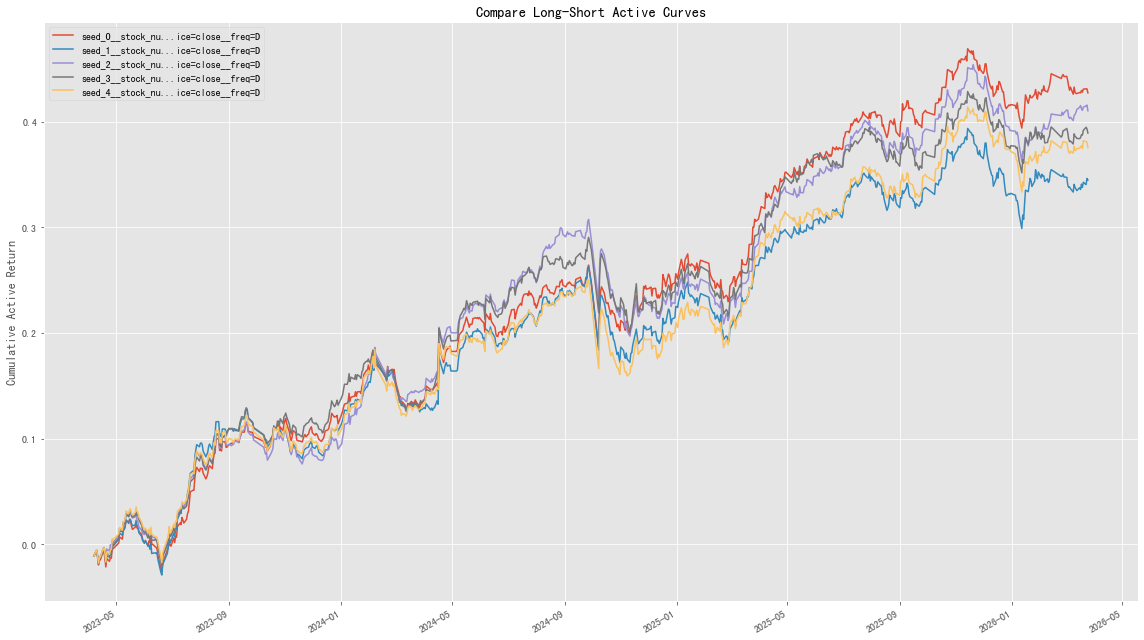

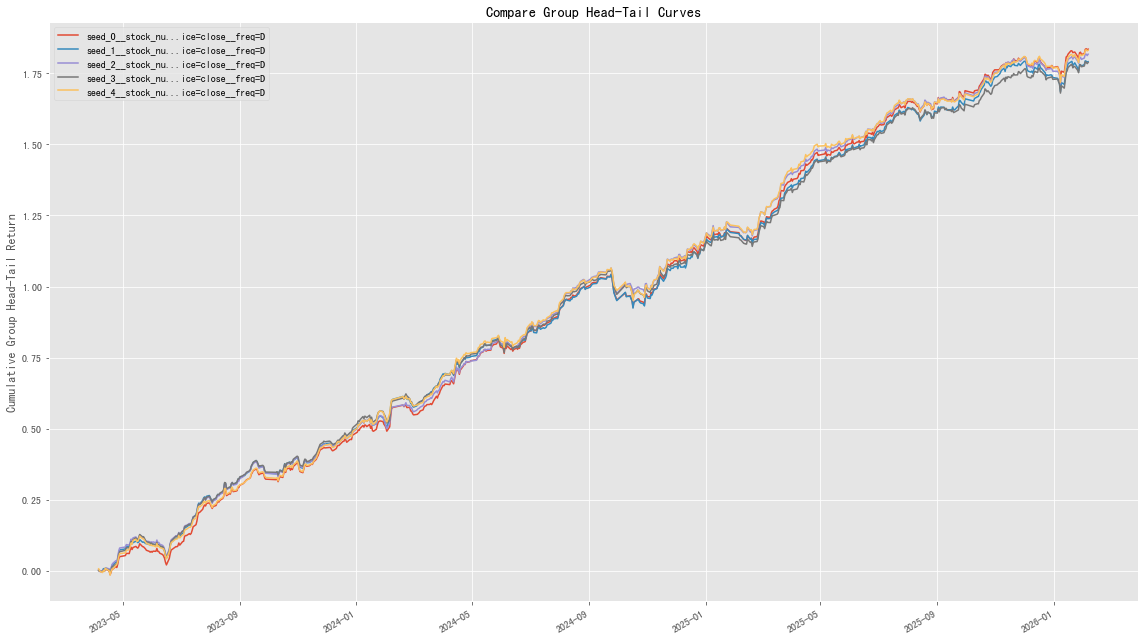

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
seed_0,0.0546,0.5050,392.0,0.1458,1.55,-0.08
seed_1,0.0550,0.5009,393.0,0.1177,1.24,-0.09
seed_2,0.0550,0.5143,393.0,0.1400,1.52,-0.11
seed_3,0.0544,0.4992,393.0,0.1328,1.40,-0.09
seed_4,0.0543,0.4999,393.0,0.1281,1.35,-0.09


In [ ]:
stock_num = 200
filtered_summary = filter_res_by_stock_num(df = compare_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = curve_df, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = group_df, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess)
plot_compare_group_head_tail(filtered_ls)
display(filter_summary(filtered_summary))

**stock_num 300组**

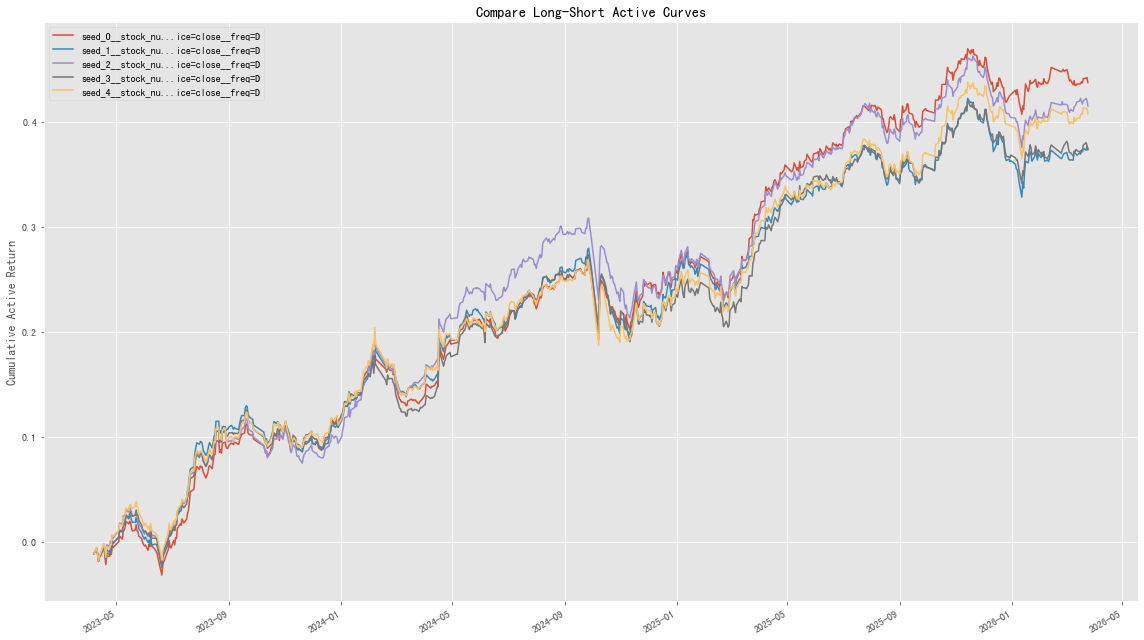

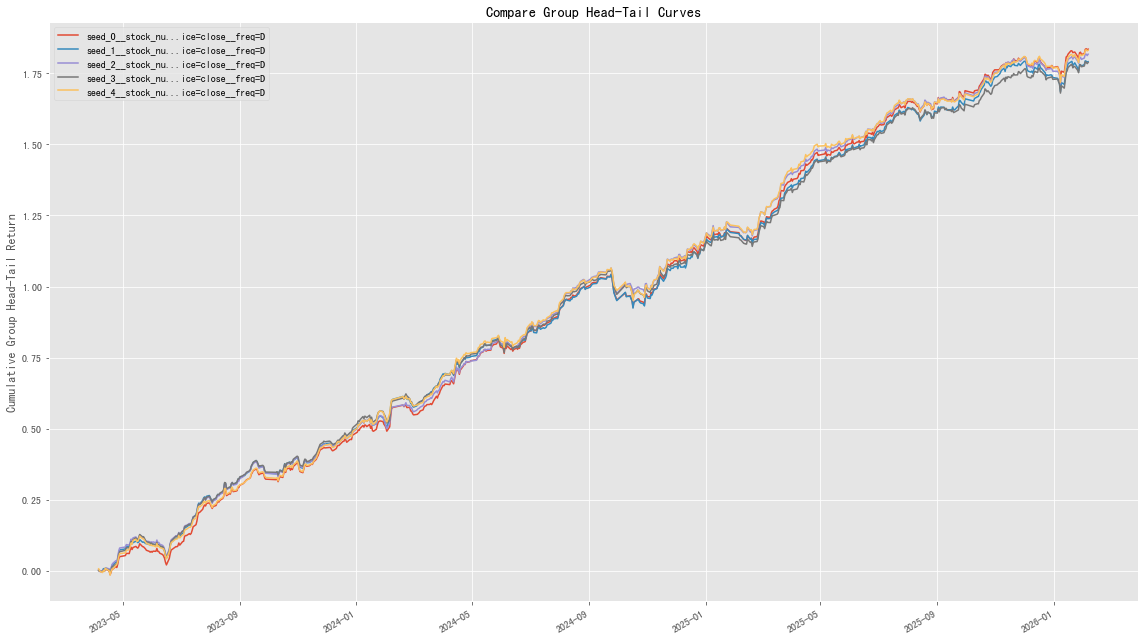

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
seed_0,0.0546,0.5050,367.0,0.1492,1.64,-0.07
seed_1,0.0550,0.5009,370.0,0.1273,1.38,-0.09
seed_2,0.0550,0.5143,369.0,0.1416,1.57,-0.09
seed_3,0.0544,0.4992,368.0,0.1277,1.40,-0.08
seed_4,0.0543,0.4999,368.0,0.1390,1.50,-0.08


In [31]:
stock_num = 300
filtered_summary = filter_res_by_stock_num(df = compare_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = curve_df, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = group_df, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess)
plot_compare_group_head_tail(filtered_ls)
display(filter_summary(filtered_summary))

**seed间随机性对比总结** 

观测这一组实验我们可以得出以下几点观察：
- ZZQZ-2000这样剥离市值风格的实验，仍然有较为稳定的超额与ic，初步说明该起点并非一个随机噪声或是完全的风格因子，有有一定的选股能力
- vol与ic在跨seed间较为稳定，annual rtn在几组实验均值14%的情况下有约1%的波动
- 且在不同选股数量下该结论都较为稳定
- 由于空头太弱，导致多空（10组）结果基本被空头dominate，所以多空表现差别相对于多头部分更小。
- 但无论从多头（超额）还是多空的对比观察，同一组实验设置下seed间差异较小，后续将seed等权合成的结果作为某一组实验设置的结果代表可以接受
---


**对比实验2：同一组超参数下不同像素定义的对比**
---

这里对于每种特征定义有两种不同的标准化处理，分别是通道内zscore和通道内logclip。因此在两种不同的标准化方式下我们都来观察一下。这里的回看周期固定为252个交易日，retrain周期固定为20个交易日

**zscore标准化组**

In [ ]:
factor_sources = build_factor_sources_from_group(
    factor_class="FactorsForTest",
    factor_group="cnn_baseline_pixel_def_zs",
)

configs = build_config_grid(
    base_config=base_config,
    param_grid={
        "stock_num": [200],
        "indus_neutral": [False],
    },
)

tasks = build_batch_tasks(
    factor_sources=factor_sources,
    configs=configs,
)

results = run_batch_tasks(
    tasks=tasks,
    n_jobs=2,
)

compare_summary = build_compare_summary(results)
curve_df = compare_long_short_curves(results)
group_df = compare_group_head_tail(results)

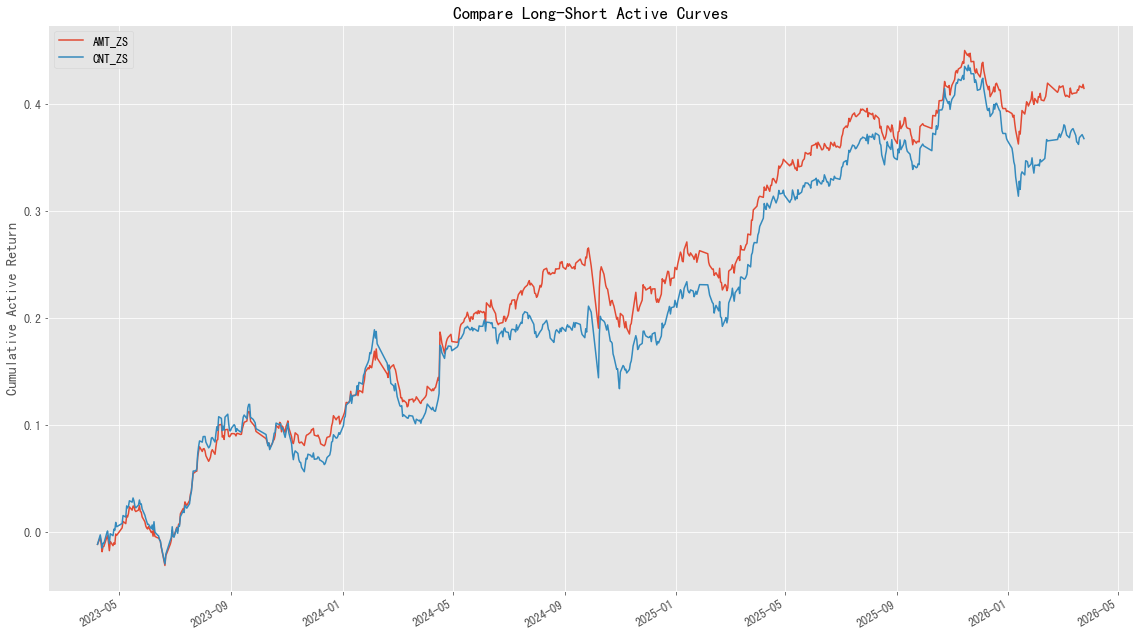

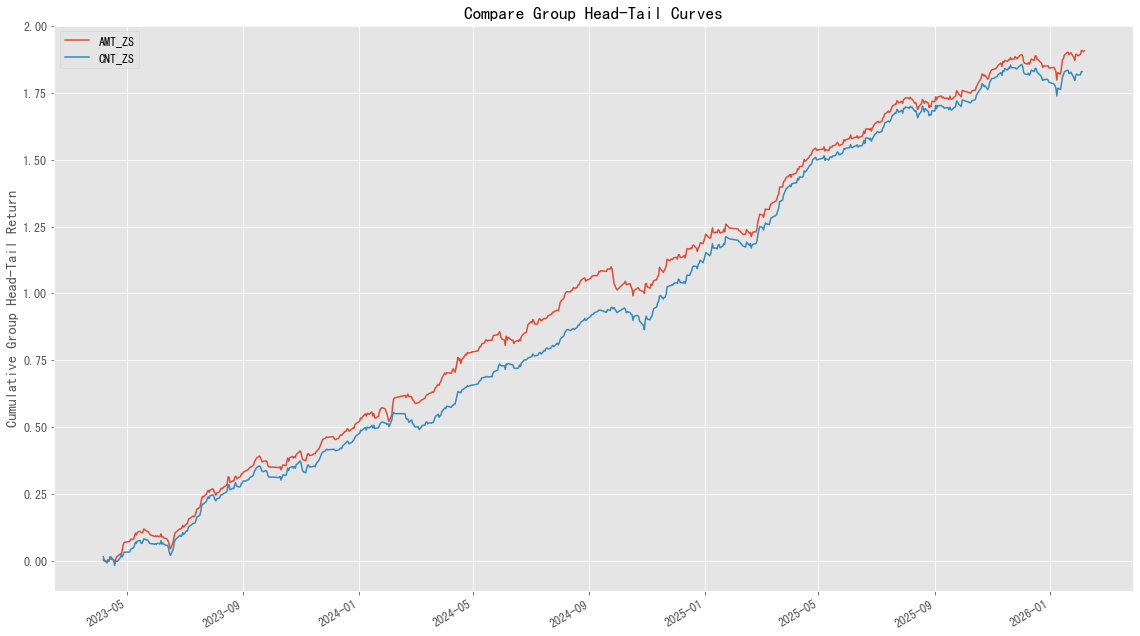

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
AMT_ZS,0.0570,0.5055,383.0,0.1413,1.50,-0.09
CNT_ZS,0.0544,0.5367,382.0,0.1254,1.26,-0.12


In [23]:
plot_compare_long_short_curves(curve_df.rename(columns=rename_rule))
plot_compare_group_head_tail(group_df.rename(columns=rename_rule))
display(filter_summary(compare_summary).rename(index=rename_rule))

**logclip标准化组**

In [ ]:
factor_sources = build_factor_sources_from_group(
    factor_class="FactorsForTest",
    factor_group="cnn_baseline_pixel_def_logclip",
)

configs = build_config_grid(
    base_config=base_config,
    param_grid={
        "stock_num": [200],
        "indus_neutral": [False],
    },
)

tasks = build_batch_tasks(
    factor_sources=factor_sources,
    configs=configs,
)

results = run_batch_tasks(
    tasks=tasks,
    n_jobs=2,
)

compare_summary = build_compare_summary(results)
curve_df = compare_long_short_curves(results)
group_df = compare_group_head_tail(results)

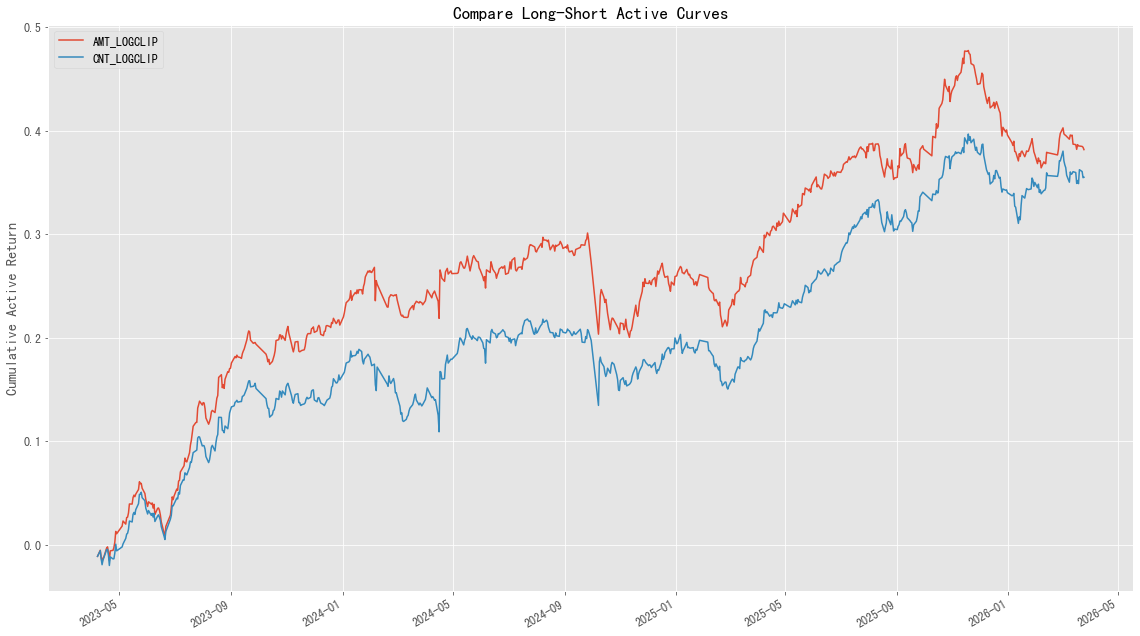

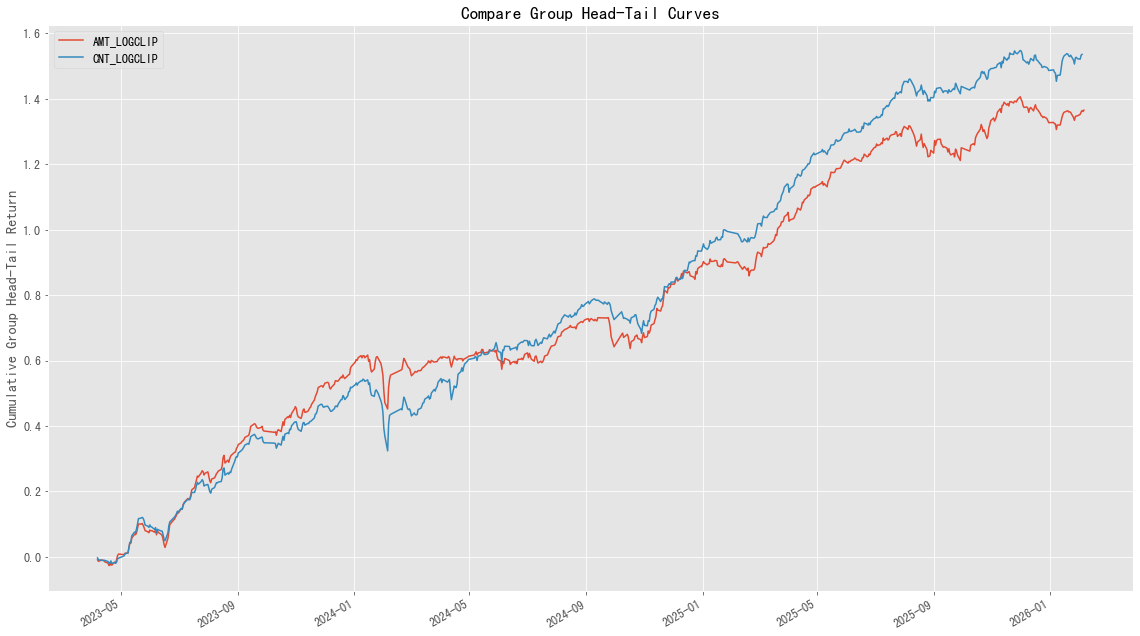

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
AMT_LOGCLIP,0.0393,0.3287,336.0,0.1302,1.28,-0.11
CNT_LOGCLIP,0.0450,0.4057,338.0,0.1211,1.23,-0.09


In [25]:
plot_compare_long_short_curves(curve_df.rename(columns=rename_rule))
plot_compare_group_head_tail(group_df.rename(columns=rename_rule))
display(filter_summary(compare_summary).rename(index=rename_rule))

**不同像素定义对比实验总结**

可以看到无论在哪种标准化处理方式的组里面，amt的像素定义都优于cnt的像素定义，这也符合我们一开始的预期：amt（金额总和）像素定义更符合“区域流动性”刻画的初衷，cnt（单总数）像素定义很容易受到拆单之类的行为污染，单的数量含义不如金额总和明确

**对比实验3: 同一个像素定义下不同特征标准化方式的对比**
---

通过上面的观察可以得出相比于cnt（单数）的像素定义，amt(总金额)的像素定义更加合理，测试结果也更加鲁棒，因此这里的对比单单在amt像素定义下

In [ ]:
factor_sources = build_factor_sources_from_group(
    factor_class="FactorsForTest",
    factor_group="cnn_baseline_pixel_norm",
)

configs = build_config_grid(
    base_config=base_config,
    param_grid={
        "stock_num": [100, 200, 300],
        "indus_neutral": [False],
    },
)

tasks = build_batch_tasks(
    factor_sources=factor_sources,
    configs=configs,
)

results = run_batch_tasks(
    tasks=tasks,
    n_jobs="auto",
)

compare_summary = build_compare_summary(results)
curve_df = compare_long_short_curves(results)
group_df = compare_group_head_tail(results)

**stock_num 100 组**

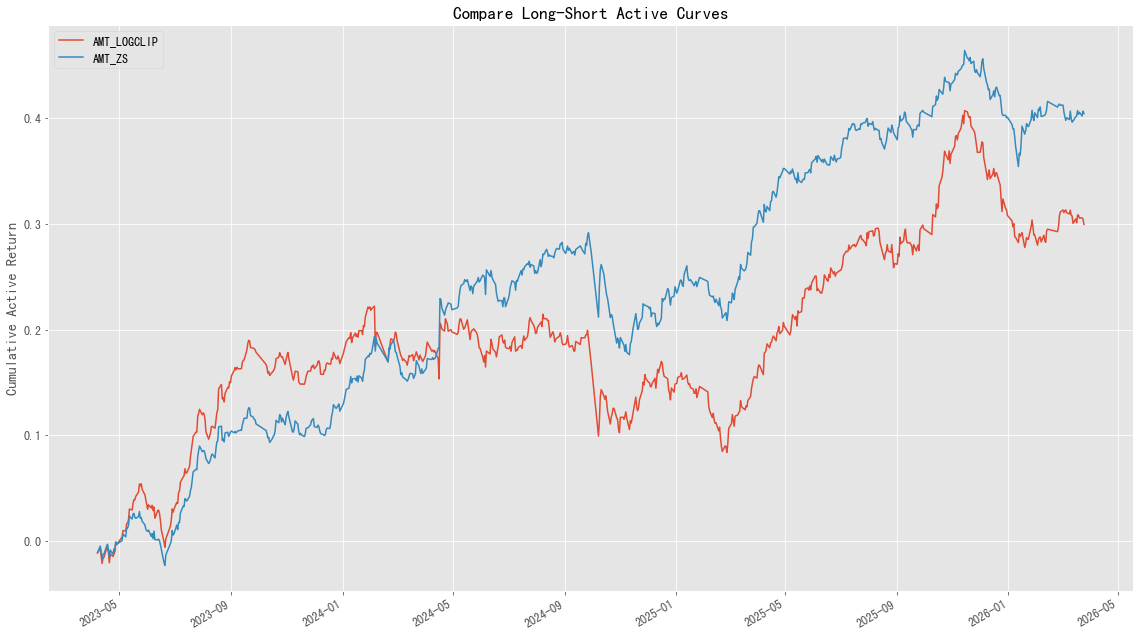

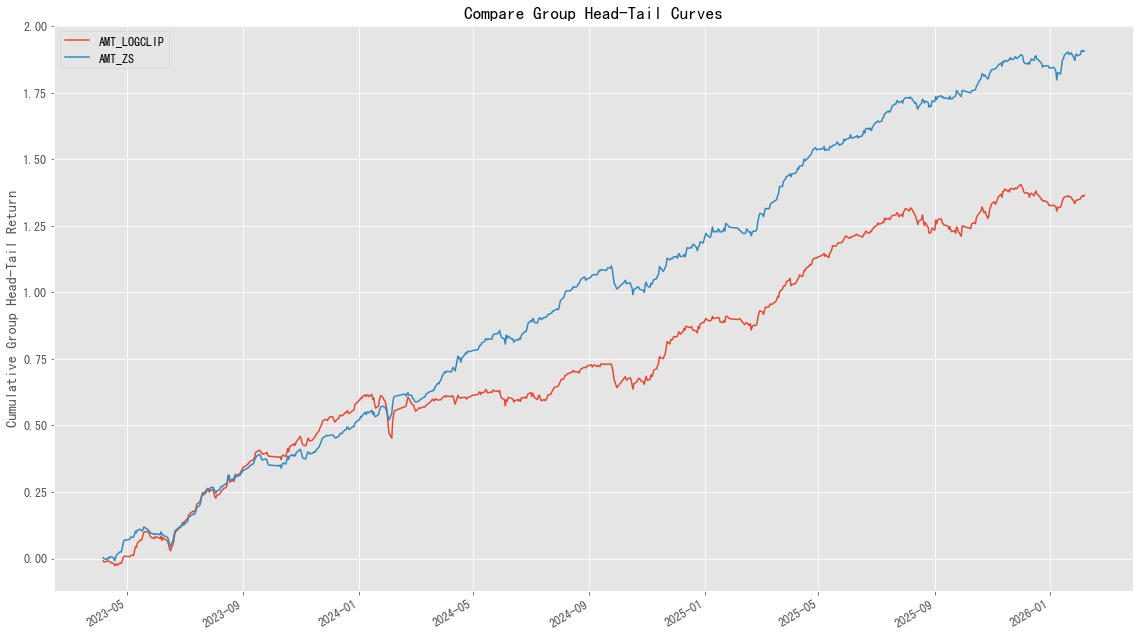

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
AMT_LOGCLIP,0.0393,0.3287,375.0,0.1022,0.92,-0.14
AMT_ZS,0.0570,0.5055,416.0,0.1379,1.39,-0.12


In [29]:
stock_num = 100
filtered_summary = filter_res_by_stock_num(df = compare_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = curve_df, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = group_df, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=rename_rule))
plot_compare_group_head_tail(filtered_ls.rename(columns=rename_rule))
display(filter_summary(filtered_summary).rename(index=rename_rule))

**stock_num 200 组**

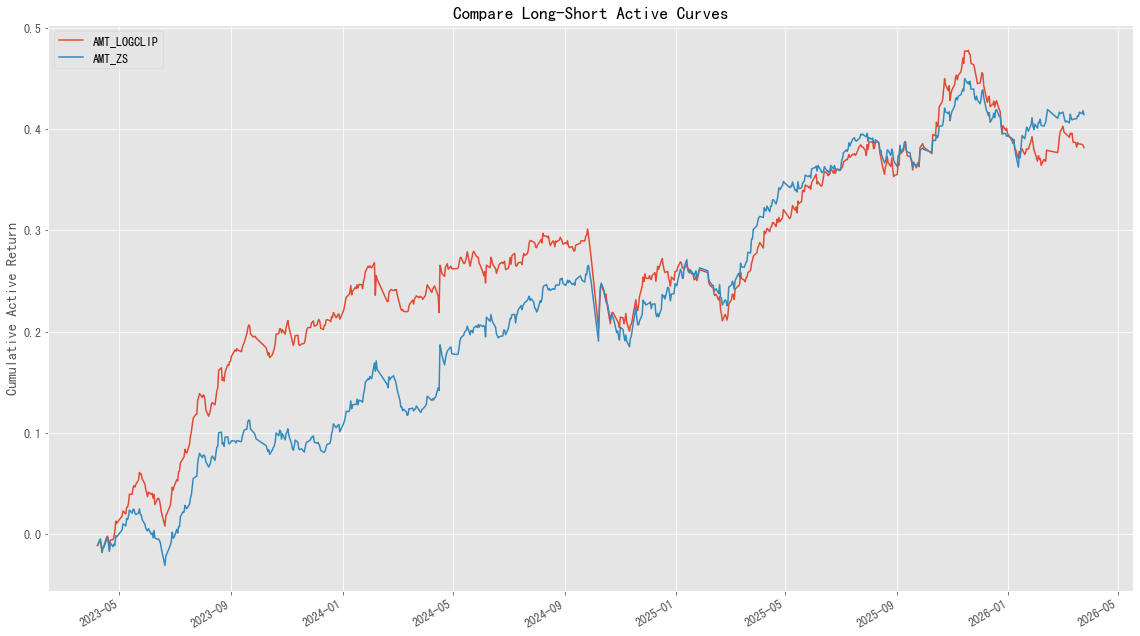

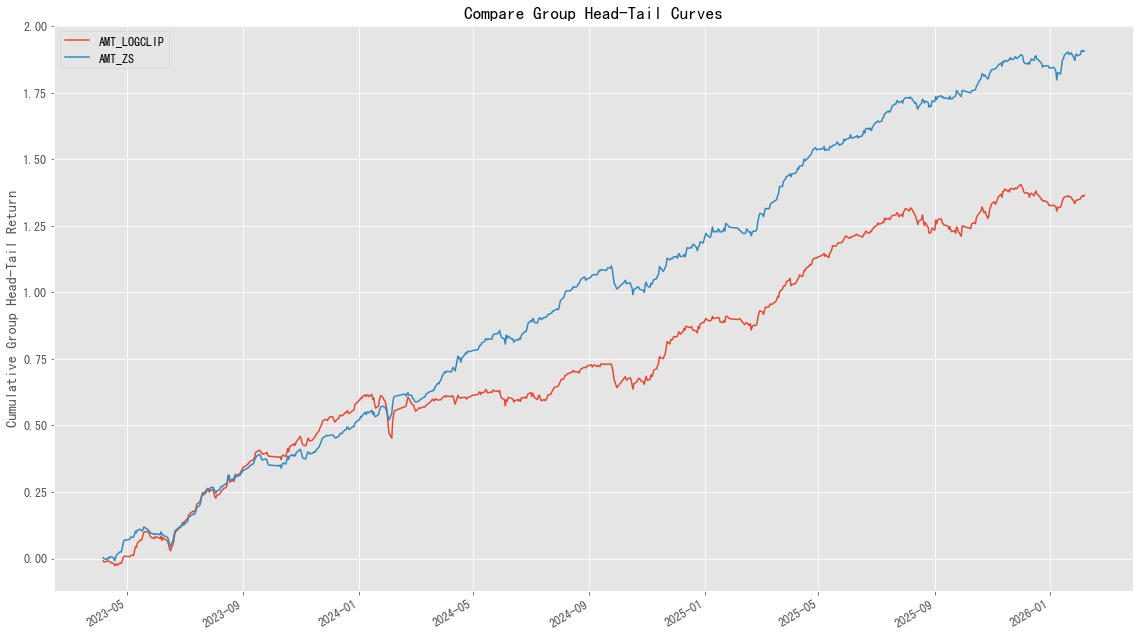

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
AMT_LOGCLIP,0.0393,0.3287,336.0,0.1302,1.28,-0.11
AMT_ZS,0.0570,0.5055,383.0,0.1413,1.50,-0.09


In [30]:
stock_num = 200
filtered_summary = filter_res_by_stock_num(df = compare_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = curve_df, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = group_df, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=rename_rule))
plot_compare_group_head_tail(filtered_ls.rename(columns=rename_rule))
display(filter_summary(filtered_summary).rename(index=rename_rule))

**stock_num 300 组**

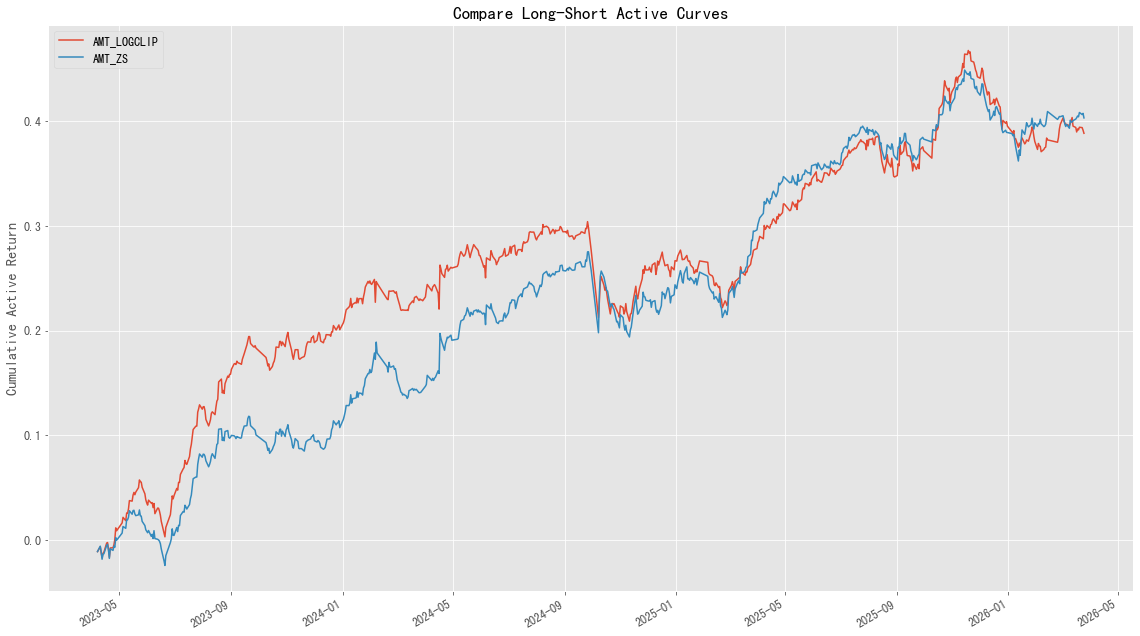

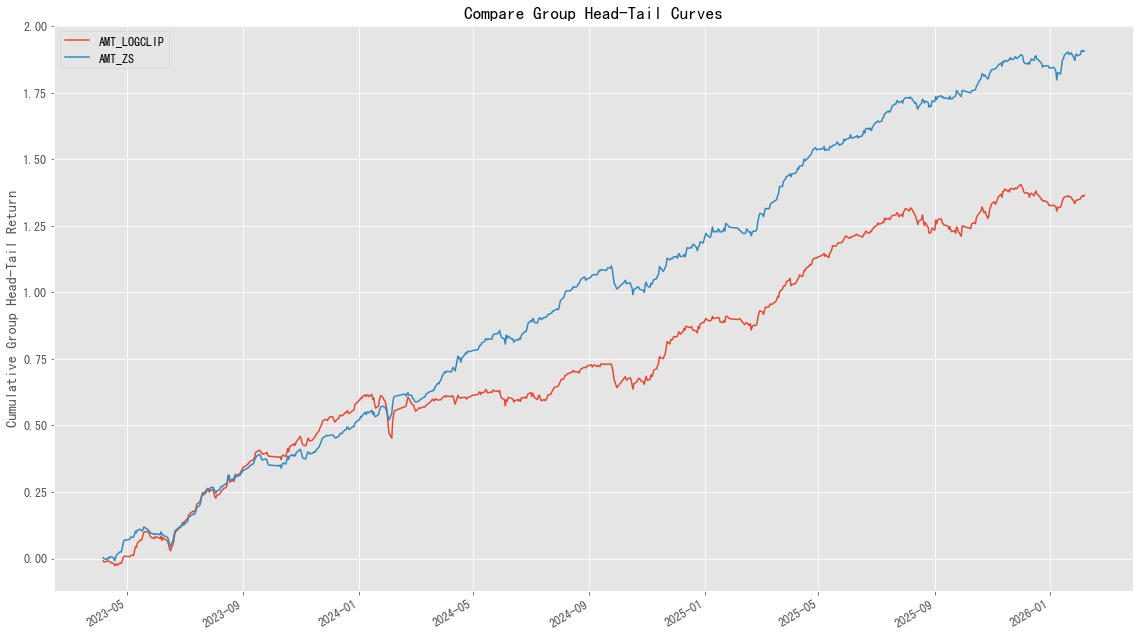

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
AMT_LOGCLIP,0.0393,0.3287,308.0,0.1325,1.39,-0.10
AMT_ZS,0.0570,0.5055,357.0,0.1375,1.49,-0.09


In [32]:
stock_num = 300
filtered_summary = filter_res_by_stock_num(df = compare_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = curve_df, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = group_df, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=rename_rule))
plot_compare_group_head_tail(filtered_ls.rename(columns=rename_rule))
display(filter_summary(filtered_summary).rename(index=rename_rule))

**不同标准化方式的总结**
在不同stock_num的测试下，通道内zscore的标准化方式都比logclip方式在IC、IR以及超额夏普等关键指标上要好，且跨组更稳定

**对比实验4.超参数对比**
---

受制于当时训练多组参数网格时只在logclip这一种标准化定义下，因此这里测试是基于此

In [ ]:
factor_sources = build_factor_sources_from_group(
    factor_class="FactorsForTest",
    factor_group="cnn_baseline_hyperprem",
)

configs = build_config_grid(
    base_config=base_config,
    param_grid={
        "stock_num": [100, 200, 300],
        "indus_neutral": [False],
    },
)

tasks = build_batch_tasks(
    factor_sources=factor_sources,
    configs=configs,
)

results = run_batch_tasks(
    tasks=tasks,
    n_jobs="auto",
)

compare_summary = build_compare_summary(results)
curve_df = compare_long_short_curves(results)
group_df = compare_group_head_tail(results)

**lookback天数对比 - 基于retrain20**

**stock_num 100**

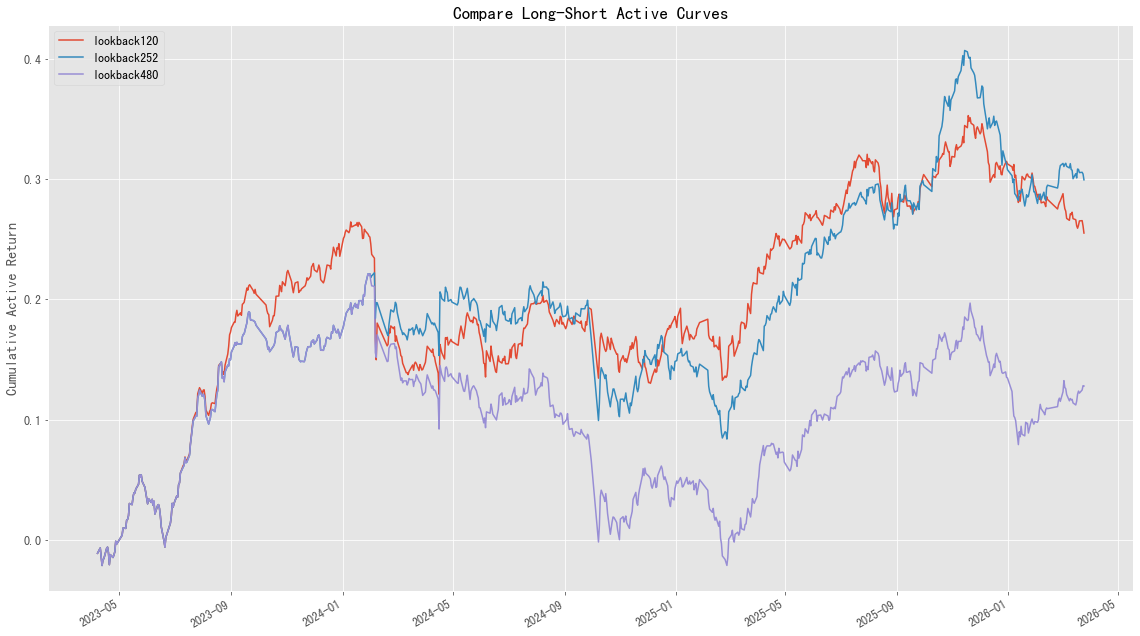

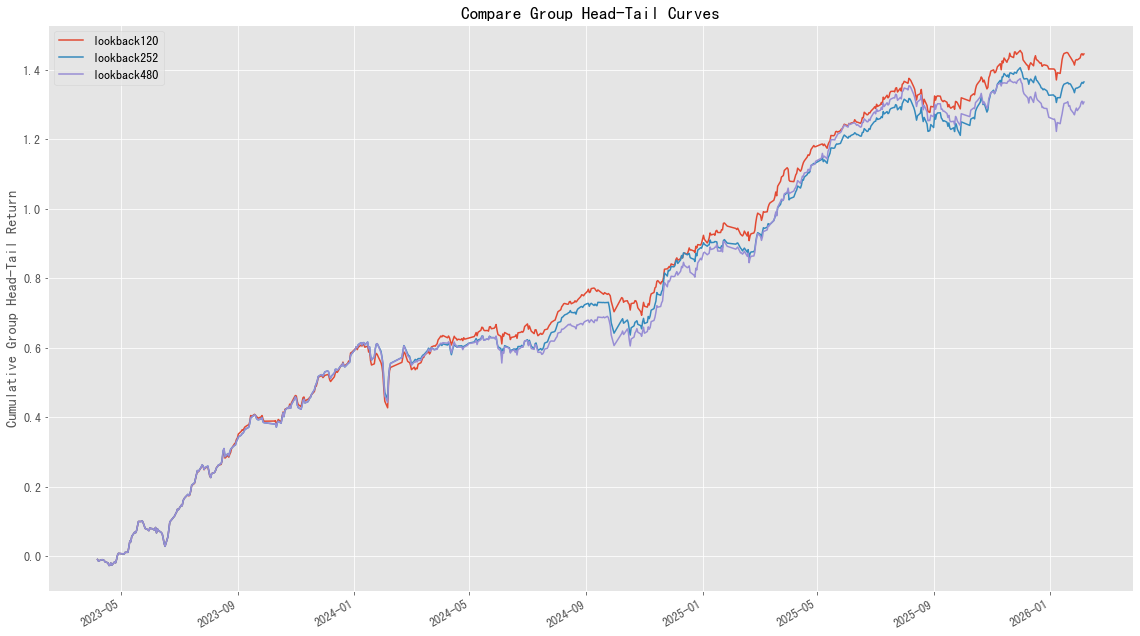

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
lookback120,0.0451,0.4012,383.0,0.0871,0.78,-0.14
lookback252,0.0393,0.3287,375.0,0.1022,0.92,-0.14
lookback480,0.0407,0.3191,373.0,0.0437,0.40,-0.24


In [44]:
stock_num = 100
retrain = 20
filtered_summary = filter_res_by_retrain(df = compare_summary, retrain=retrain, index_or_col="index")
filtered_excess = filter_res_by_retrain(df = curve_df, retrain=retrain, index_or_col="column")
filtered_ls = filter_res_by_retrain(df = group_df, retrain=retrain, index_or_col="column")

filtered_summary = filter_res_by_stock_num(df = filtered_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = filtered_excess, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = filtered_ls, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=strip_name))
plot_compare_group_head_tail(filtered_ls.rename(columns=strip_name))
display(filter_summary(filtered_summary).rename(index=strip_name))

**stock_num 200**

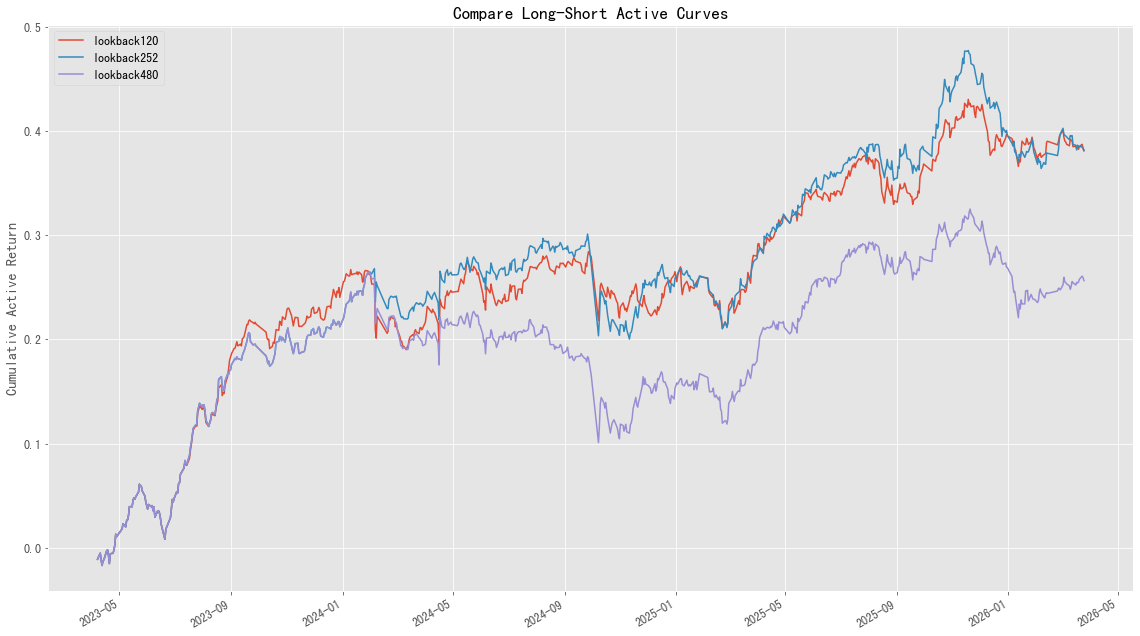

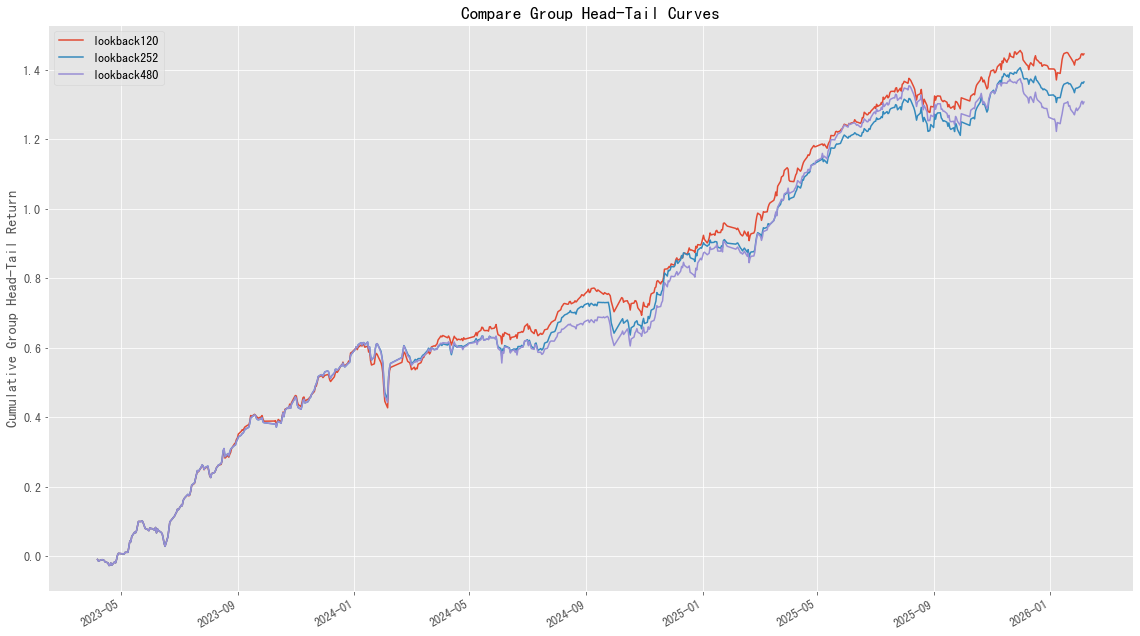

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
lookback120,0.0451,0.4012,342.0,0.1300,1.30,-0.08
lookback252,0.0393,0.3287,336.0,0.1302,1.28,-0.11
lookback480,0.0407,0.3191,334.0,0.0875,0.88,-0.16


In [43]:
stock_num = 200
retrain = 20
filtered_summary = filter_res_by_retrain(df = compare_summary, retrain=retrain, index_or_col="index")
filtered_excess = filter_res_by_retrain(df = curve_df, retrain=retrain, index_or_col="column")
filtered_ls = filter_res_by_retrain(df = group_df, retrain=retrain, index_or_col="column")

filtered_summary = filter_res_by_stock_num(df = filtered_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = filtered_excess, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = filtered_ls, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=strip_name))
plot_compare_group_head_tail(filtered_ls.rename(columns=strip_name))
display(filter_summary(filtered_summary).rename(index=strip_name))

**stock_num 300**

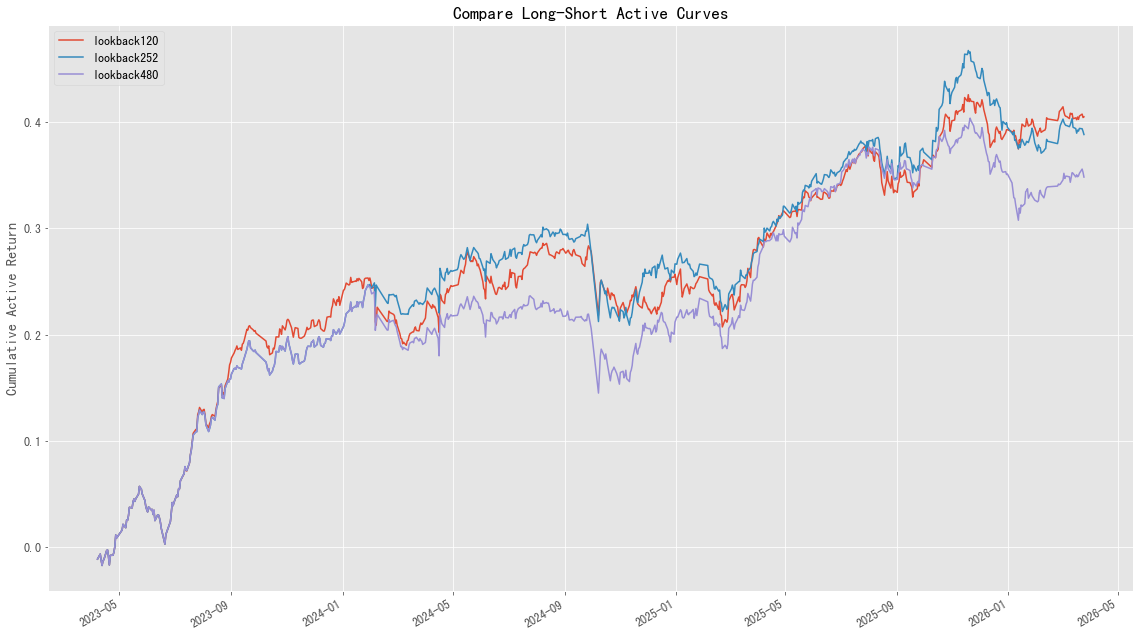

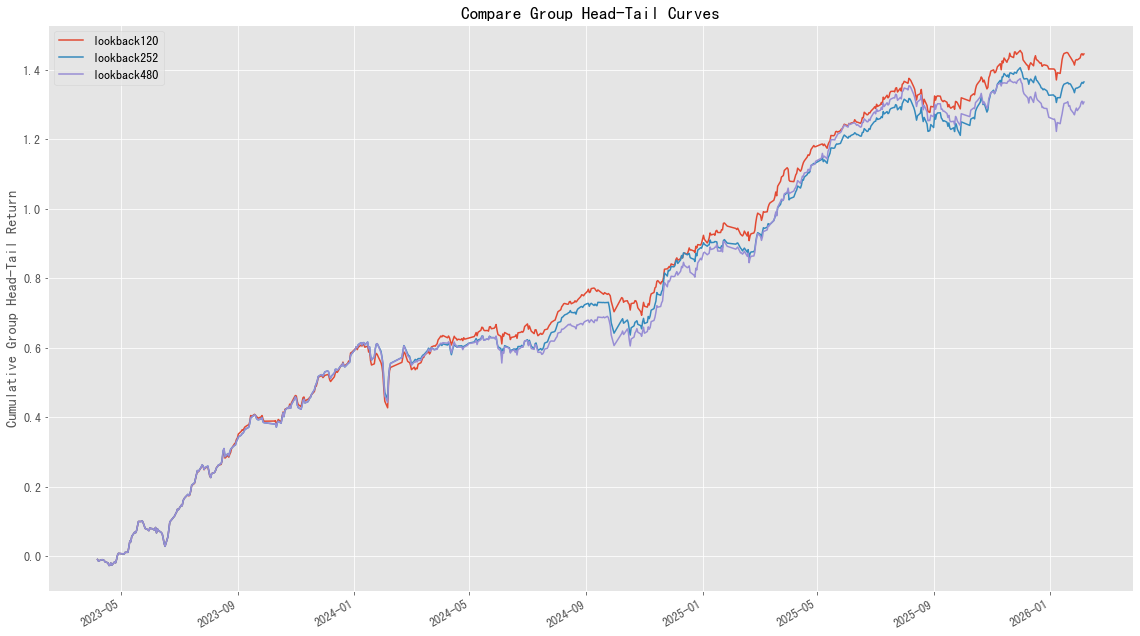

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
lookback120,0.0451,0.4012,312.0,0.1382,1.48,-0.08
lookback252,0.0393,0.3287,308.0,0.1325,1.39,-0.10
lookback480,0.0407,0.3191,305.0,0.1188,1.28,-0.10


In [45]:
stock_num = 300
retrain = 20
filtered_summary = filter_res_by_retrain(df = compare_summary, retrain=retrain, index_or_col="index")
filtered_excess = filter_res_by_retrain(df = curve_df, retrain=retrain, index_or_col="column")
filtered_ls = filter_res_by_retrain(df = group_df, retrain=retrain, index_or_col="column")

filtered_summary = filter_res_by_stock_num(df = filtered_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = filtered_excess, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = filtered_ls, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=strip_name))
plot_compare_group_head_tail(filtered_ls.rename(columns=strip_name))
display(filter_summary(filtered_summary).rename(index=strip_name))

**retrain周期对比 - 基于lookback252**

**stock_num 100**

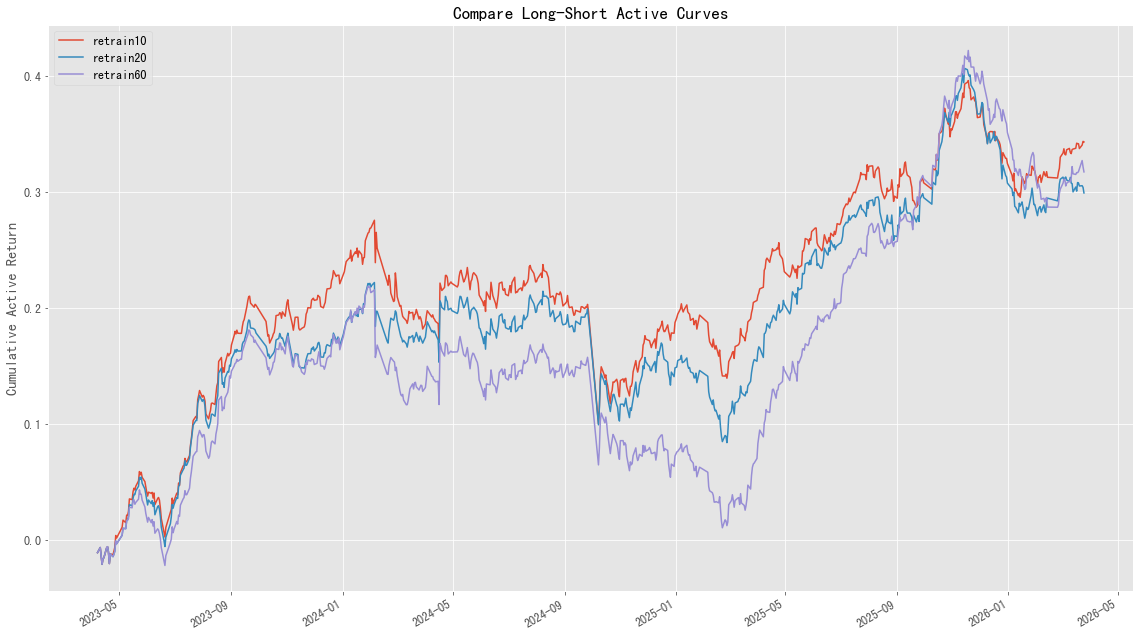

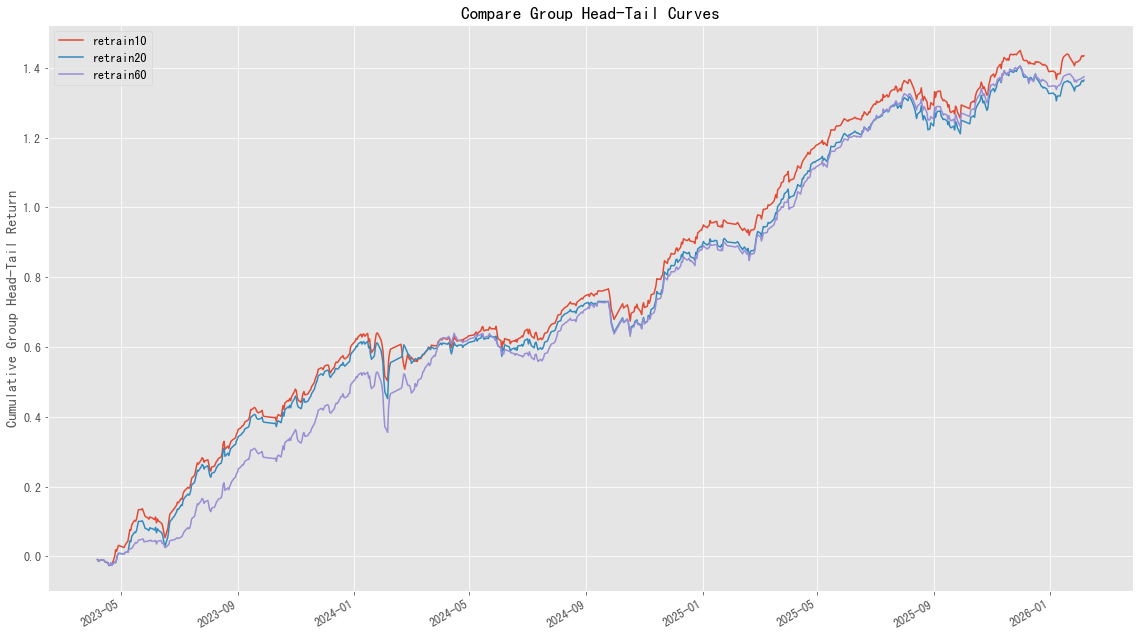

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
retrain10,0.0405,0.3291,375.0,0.1172,1.05,-0.18
retrain20,0.0393,0.3287,375.0,0.1022,0.92,-0.14
retrain60,0.0409,0.3507,356.0,0.1084,0.96,-0.21


In [48]:
stock_num = 100
lookback = 252
filtered_summary = filter_res_by_lookback(df = compare_summary, lookback=lookback, index_or_col="index")
filtered_excess = filter_res_by_lookback(df = curve_df, lookback=lookback, index_or_col="column")
filtered_ls = filter_res_by_lookback(df = group_df, lookback=lookback, index_or_col="column")

filtered_summary = filter_res_by_stock_num(df = filtered_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = filtered_excess, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = filtered_ls, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=strip_name))
plot_compare_group_head_tail(filtered_ls.rename(columns=strip_name))
display(filter_summary(filtered_summary).rename(index=strip_name))

**stock_num 200**

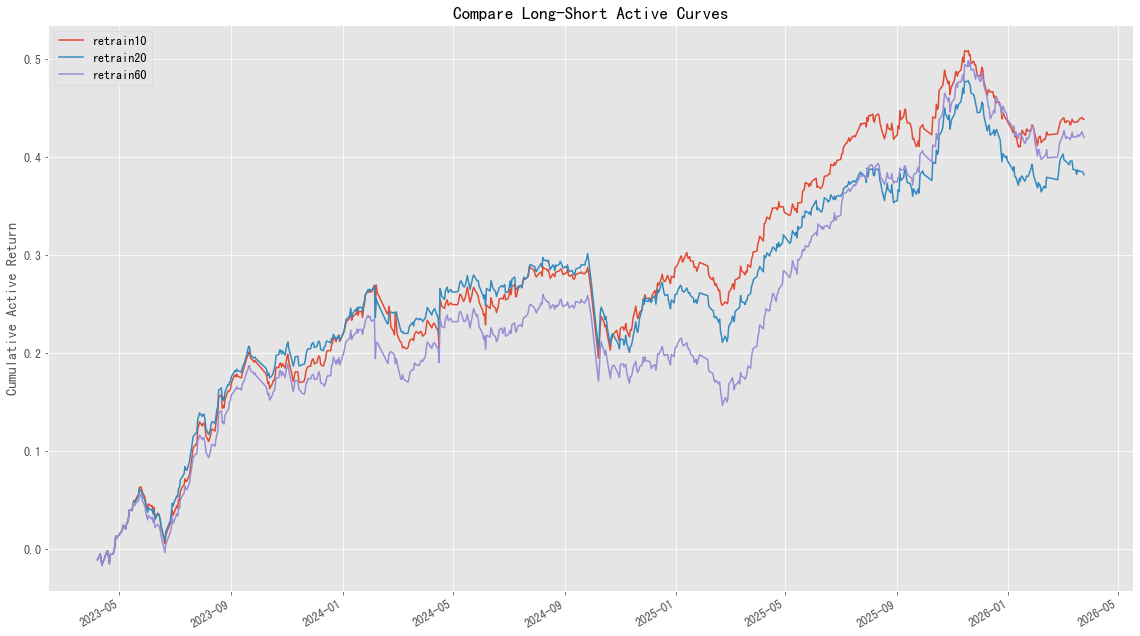

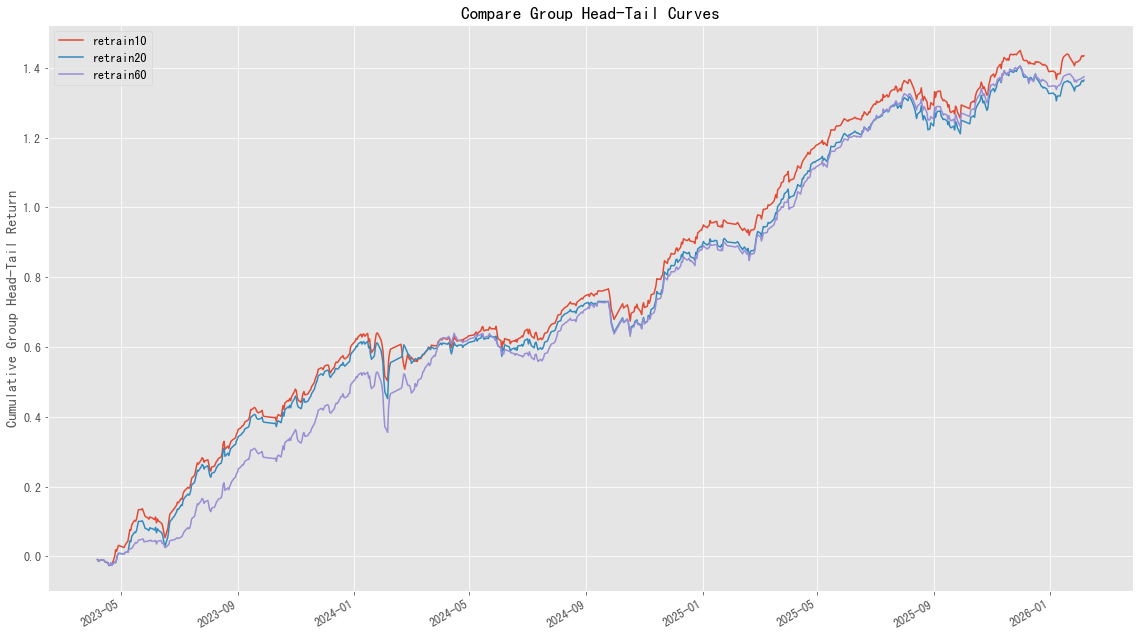

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
retrain10,0.0405,0.3291,336.0,0.1495,1.47,-0.10
retrain20,0.0393,0.3287,336.0,0.1302,1.28,-0.11
retrain60,0.0409,0.3507,317.0,0.1432,1.41,-0.11


In [49]:
stock_num = 200
lookback = 252
filtered_summary = filter_res_by_lookback(df = compare_summary, lookback=lookback, index_or_col="index")
filtered_excess = filter_res_by_lookback(df = curve_df, lookback=lookback, index_or_col="column")
filtered_ls = filter_res_by_lookback(df = group_df, lookback=lookback, index_or_col="column")

filtered_summary = filter_res_by_stock_num(df = filtered_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = filtered_excess, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = filtered_ls, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=strip_name))
plot_compare_group_head_tail(filtered_ls.rename(columns=strip_name))
display(filter_summary(filtered_summary).rename(index=strip_name))

**stock_num 300**

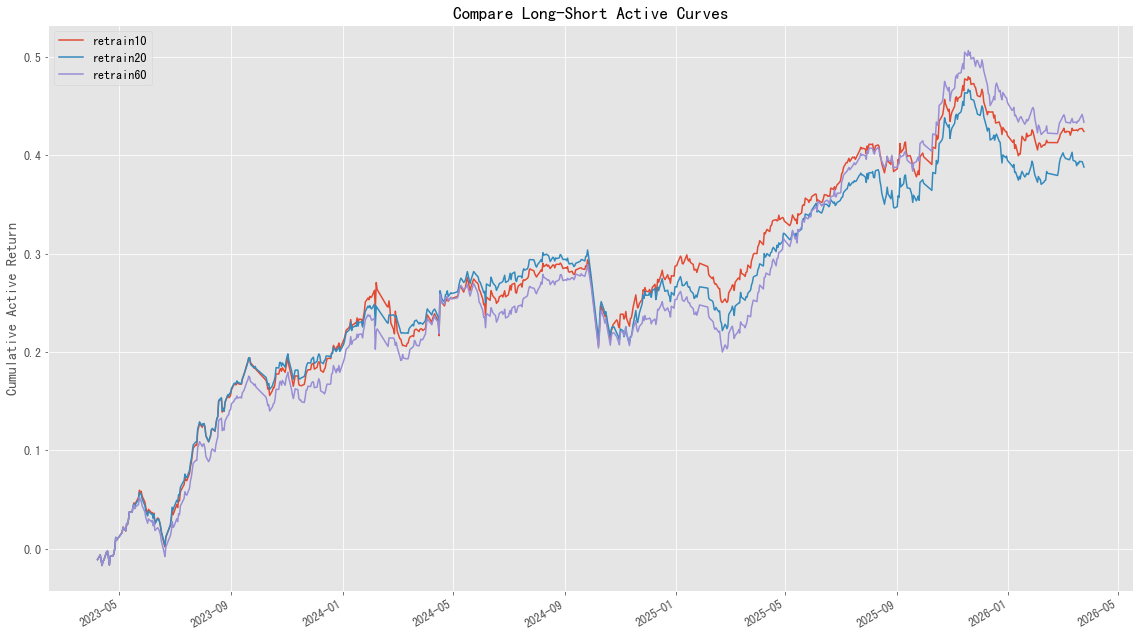

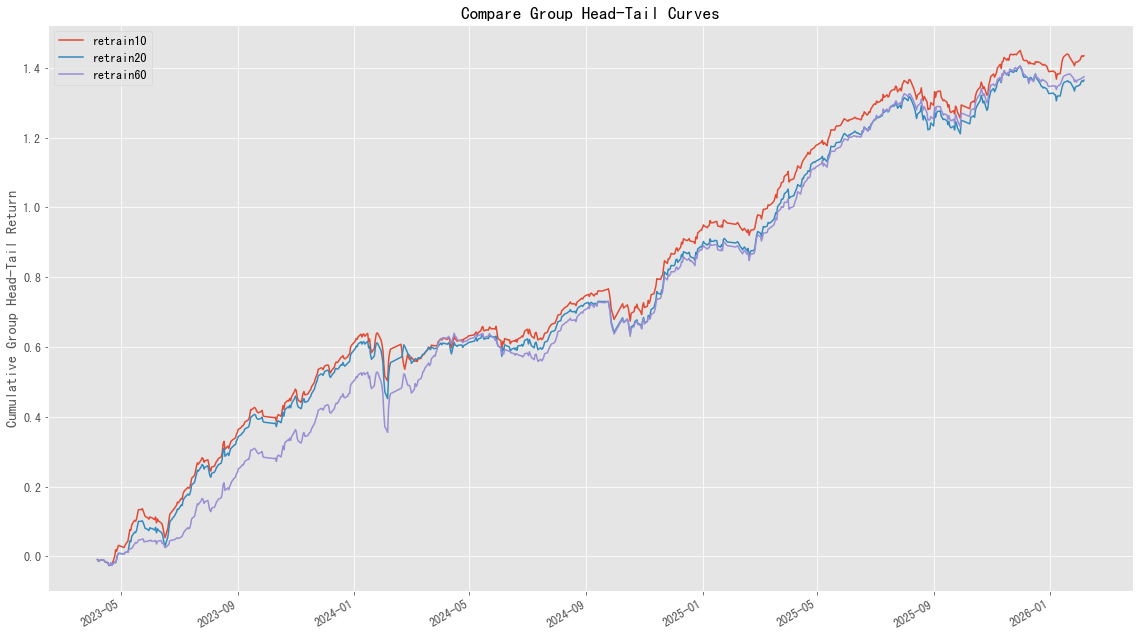

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
retrain10,0.0405,0.3291,308.0,0.1448,1.51,-0.09
retrain20,0.0393,0.3287,308.0,0.1325,1.39,-0.10
retrain60,0.0409,0.3507,289.0,0.1480,1.56,-0.09


In [50]:
stock_num = 300
lookback = 252
filtered_summary = filter_res_by_lookback(df = compare_summary, lookback=lookback, index_or_col="index")
filtered_excess = filter_res_by_lookback(df = curve_df, lookback=lookback, index_or_col="column")
filtered_ls = filter_res_by_lookback(df = group_df, lookback=lookback, index_or_col="column")

filtered_summary = filter_res_by_stock_num(df = filtered_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = filtered_excess, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = filtered_ls, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess.rename(columns=strip_name))
plot_compare_group_head_tail(filtered_ls.rename(columns=strip_name))
display(filter_summary(filtered_summary).rename(index=strip_name))

随着stock_num的增加，无论是lookback还是retrain周期的组间区别会逐渐缩小。综合lookback与retrain两个超参数来看，基于目前的特征设定（amt为像素定义）+标准化方式（logclip）+预测目标（future 5 return）下，更推荐 适中lookback+适中retrain

**还需要补充的实验：基于通道内zscore的标准化方式+amt像素定义的系列实验**

**推荐的设定下单因子详细观察**
---

**推荐设置**
- 像素定义：amt 金额总和
- 特征标准化方式：通道内zscore
- lookback：252 trading days
- retrain： 20 days
- target: horizon 5 + sectional_rank_pct

718 days to simulate
run==>1.239S
0 idx day 20061229 < first cat day 20070104
run==>4.482S


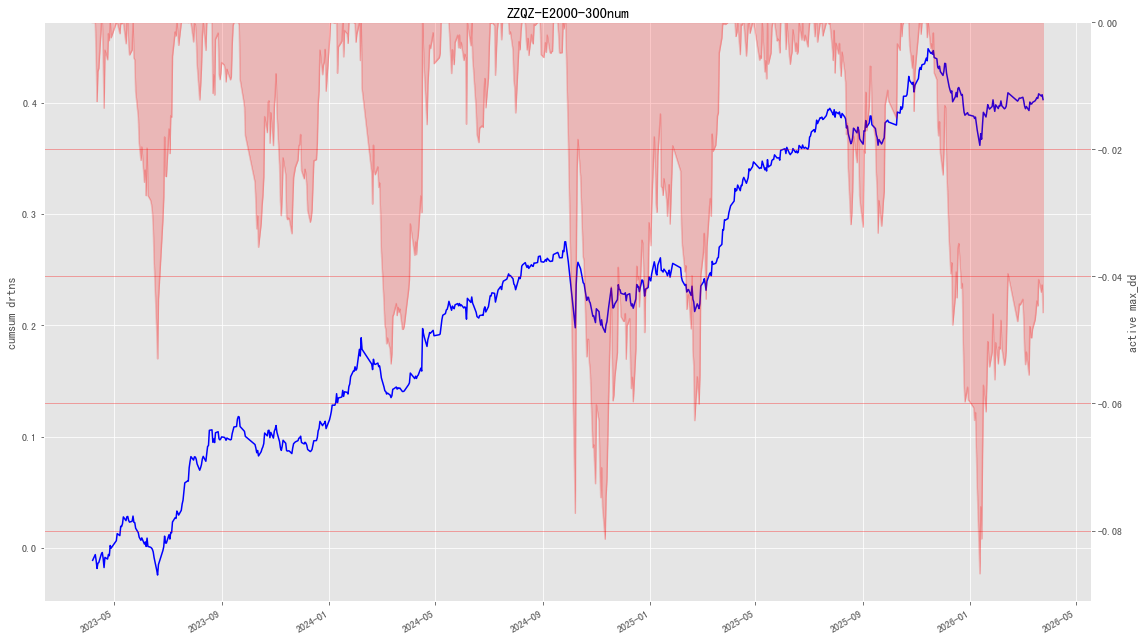

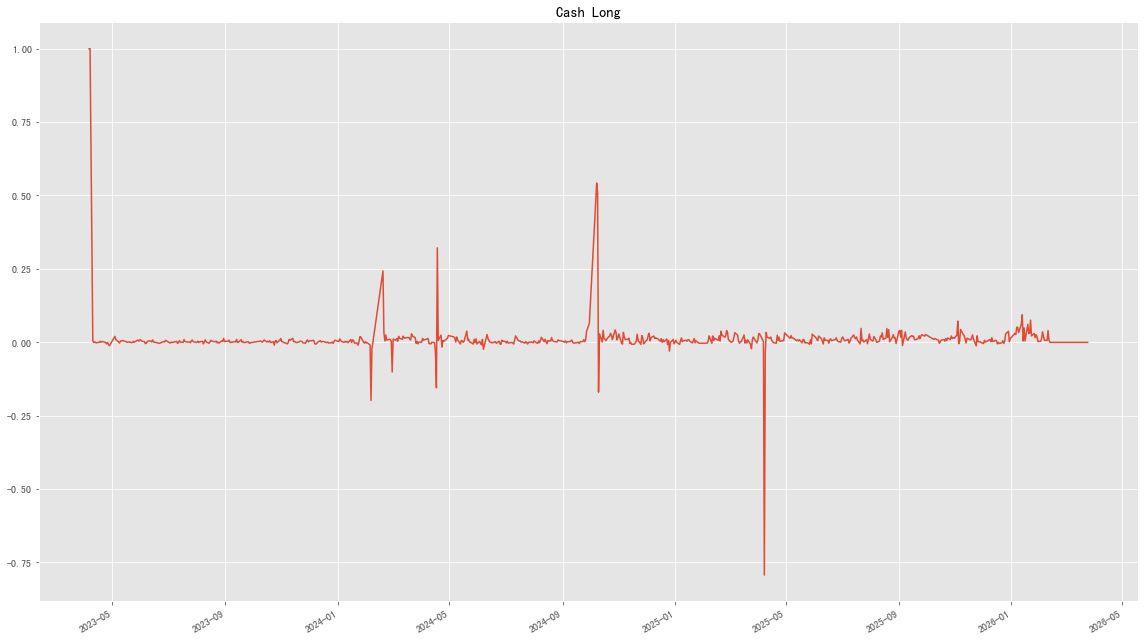

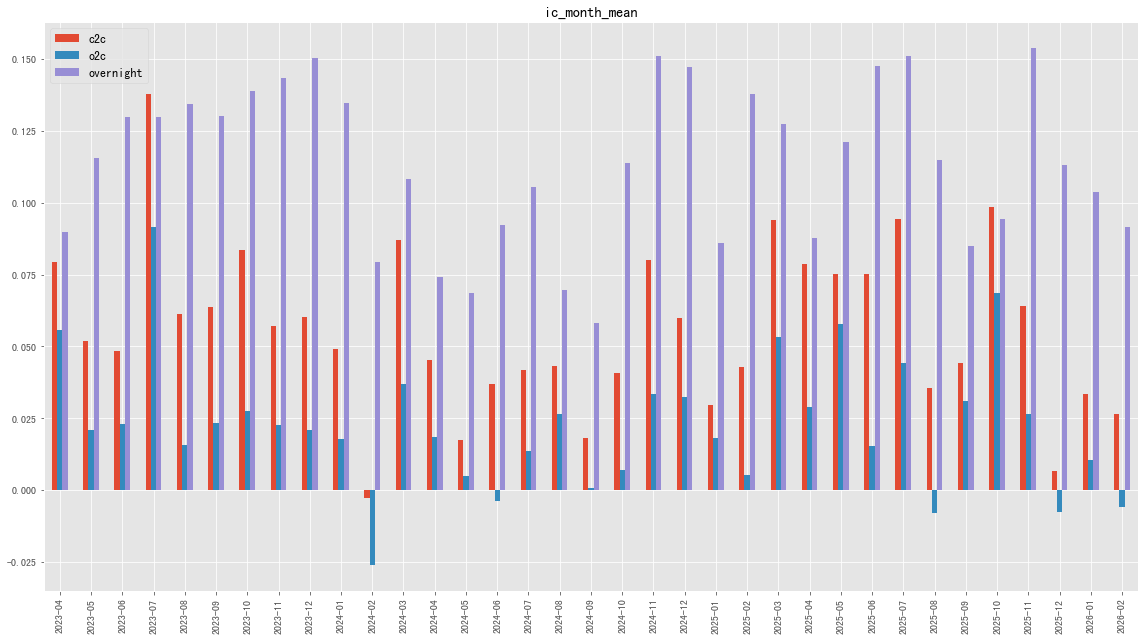

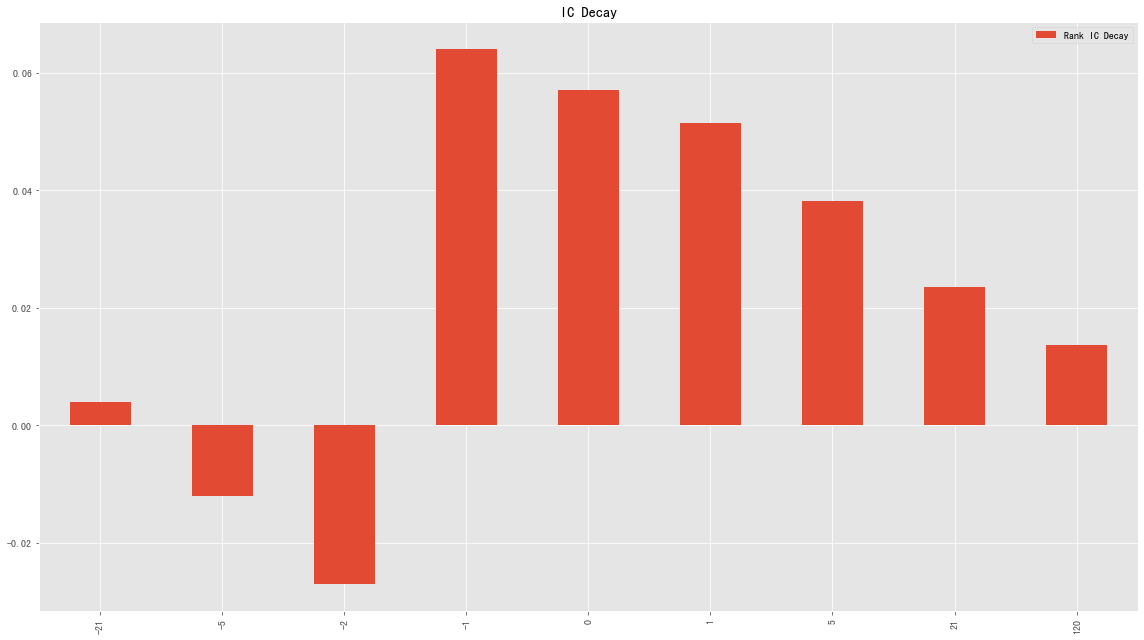

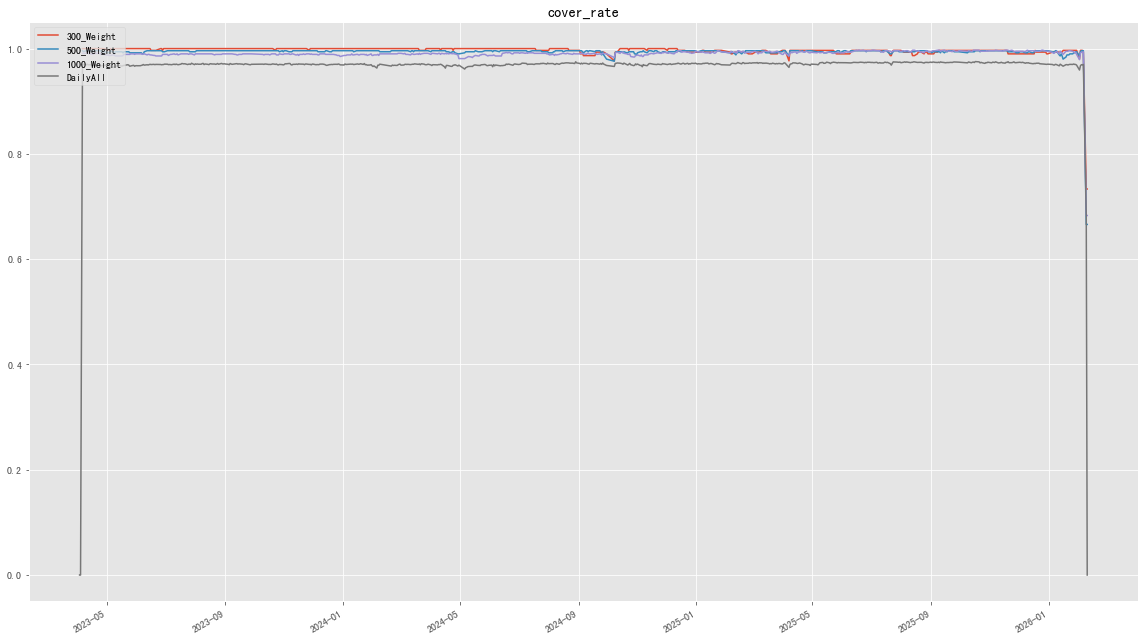

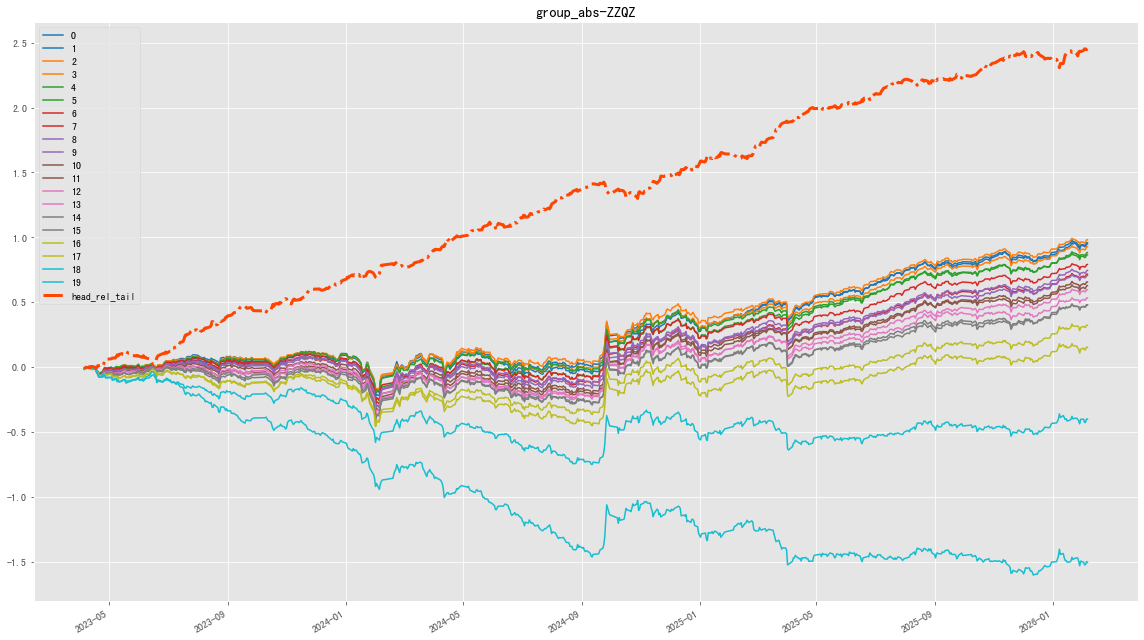

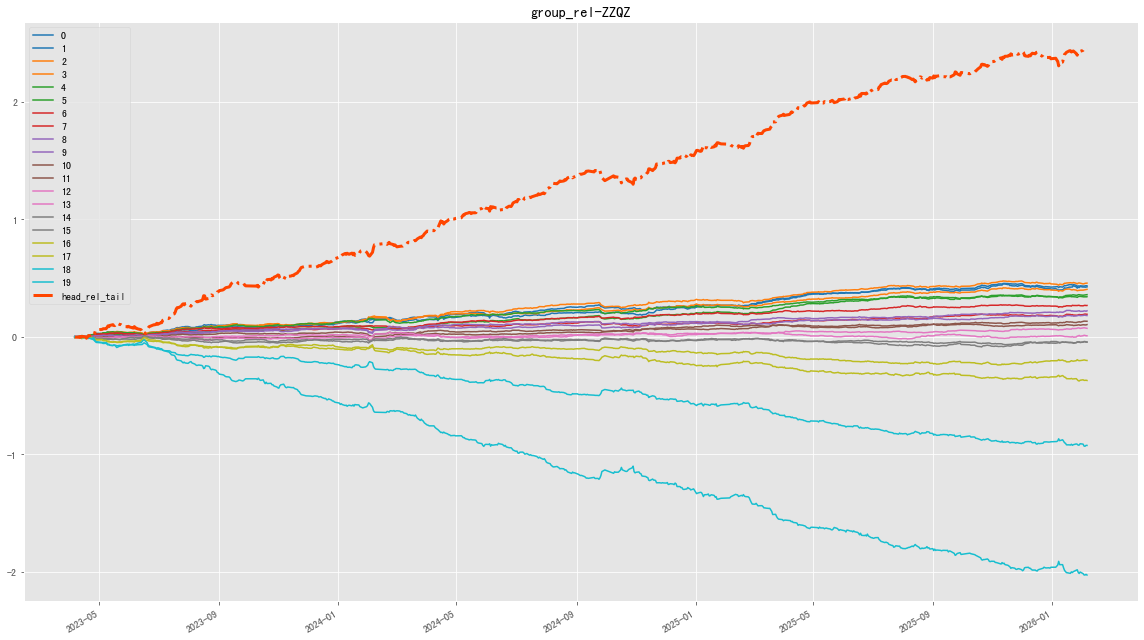

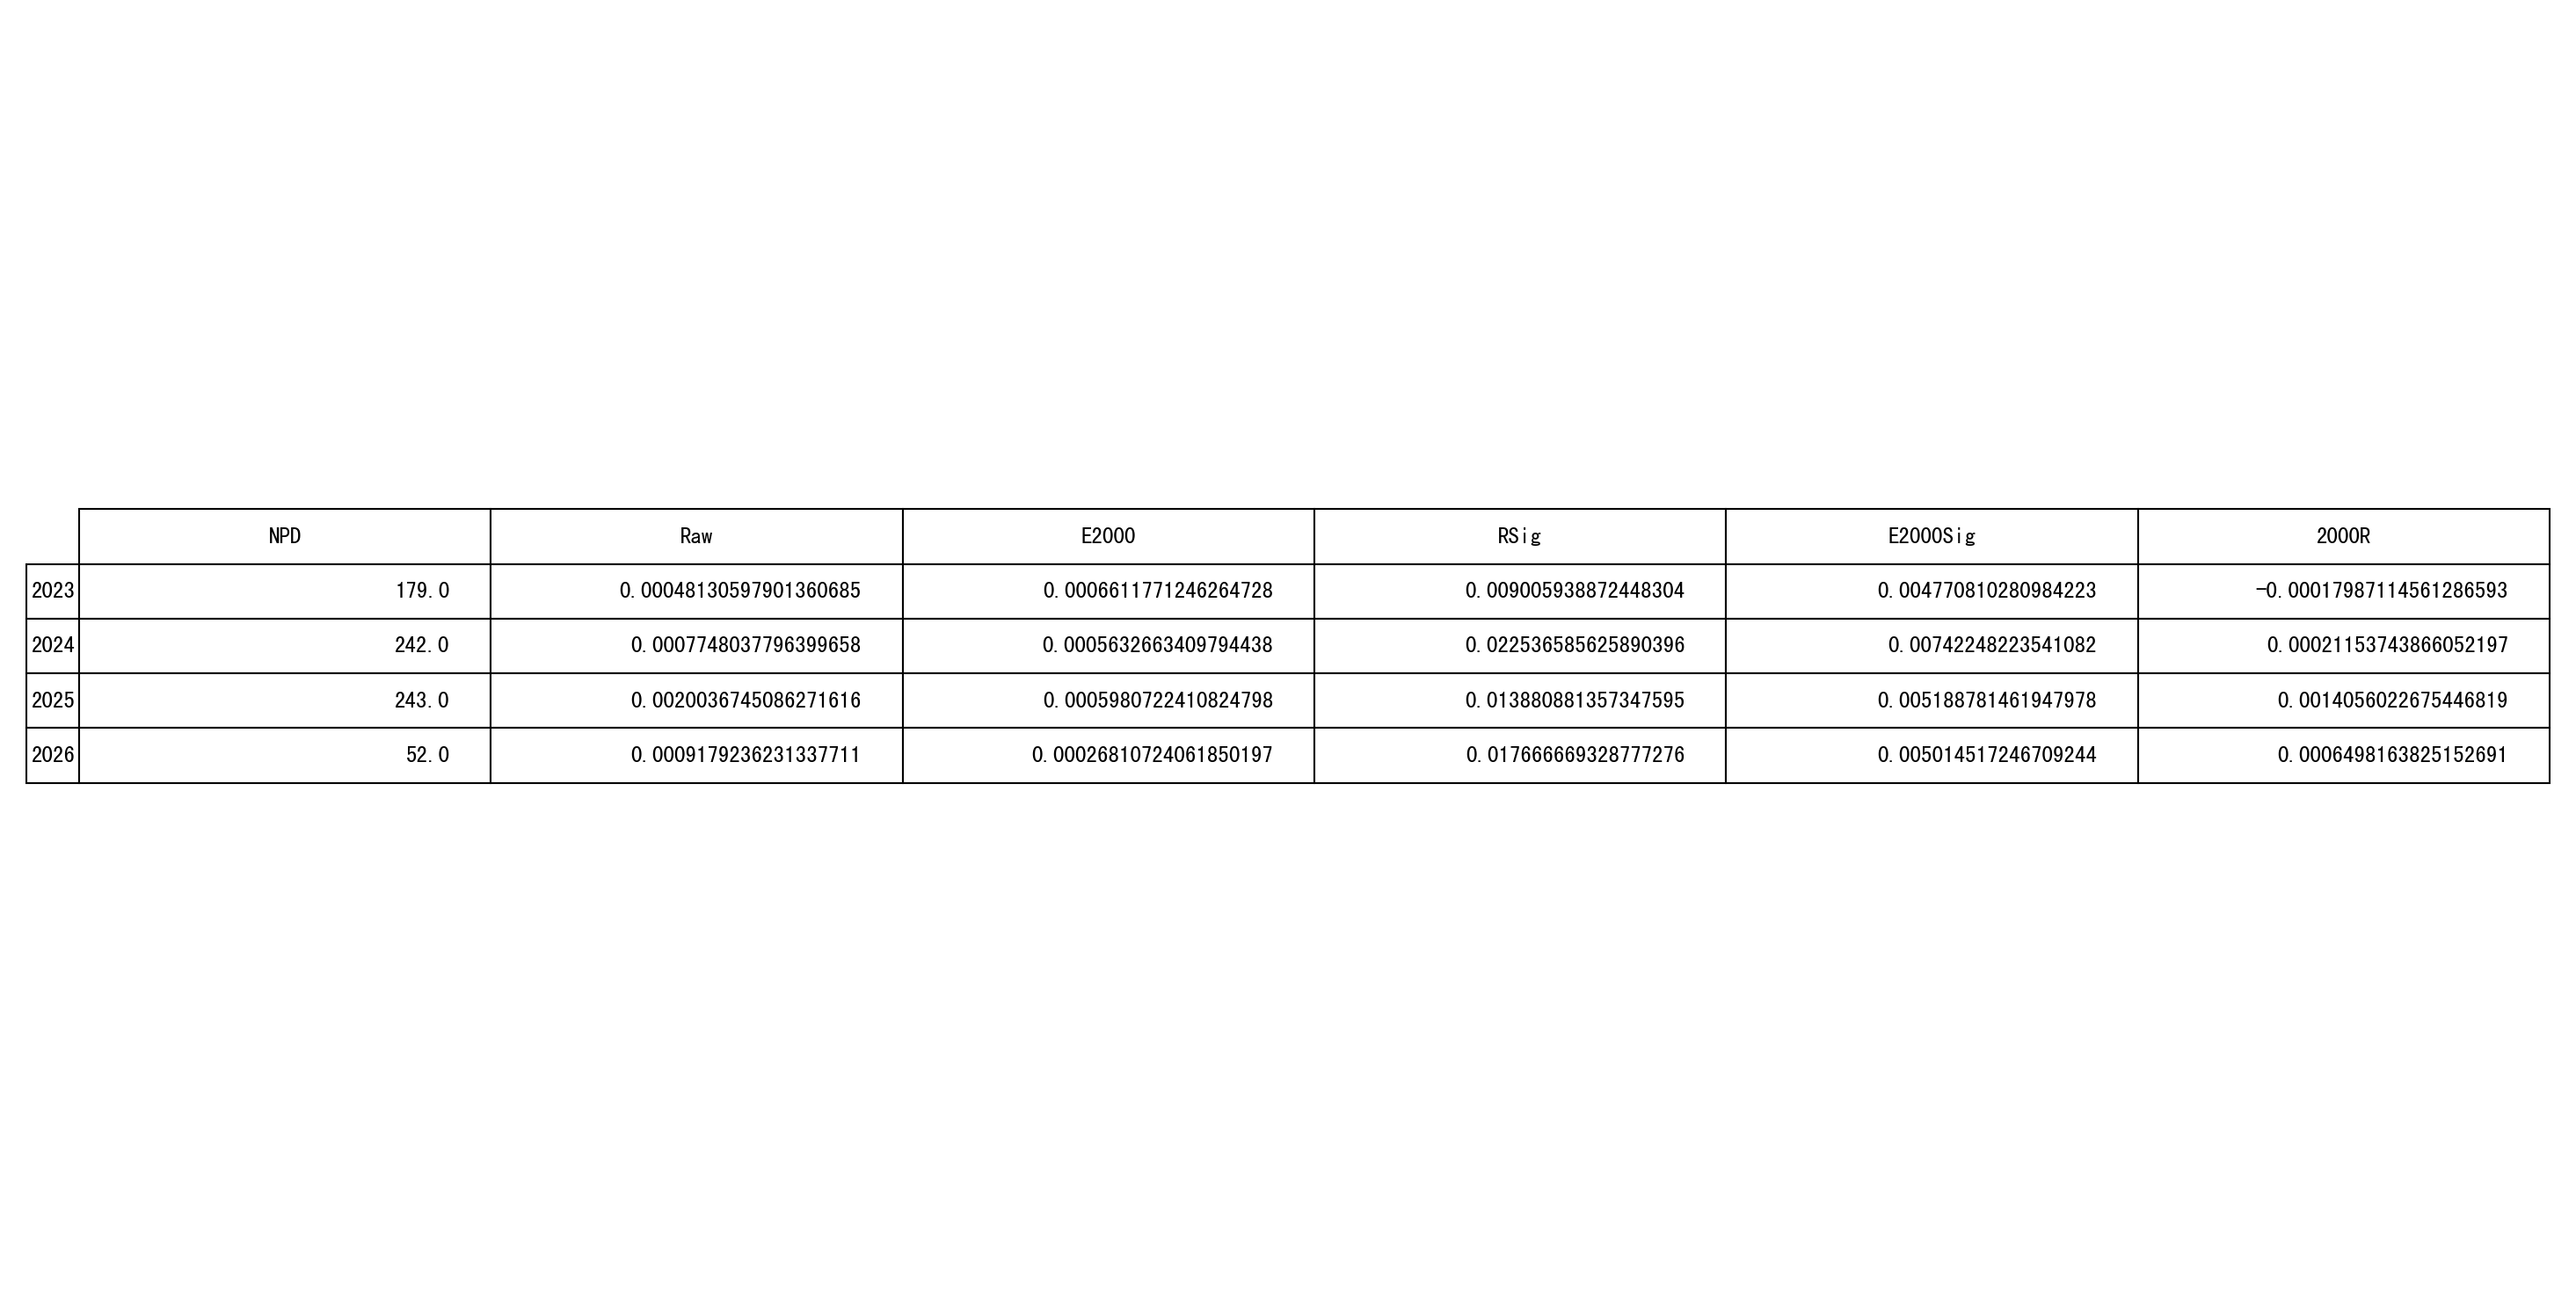

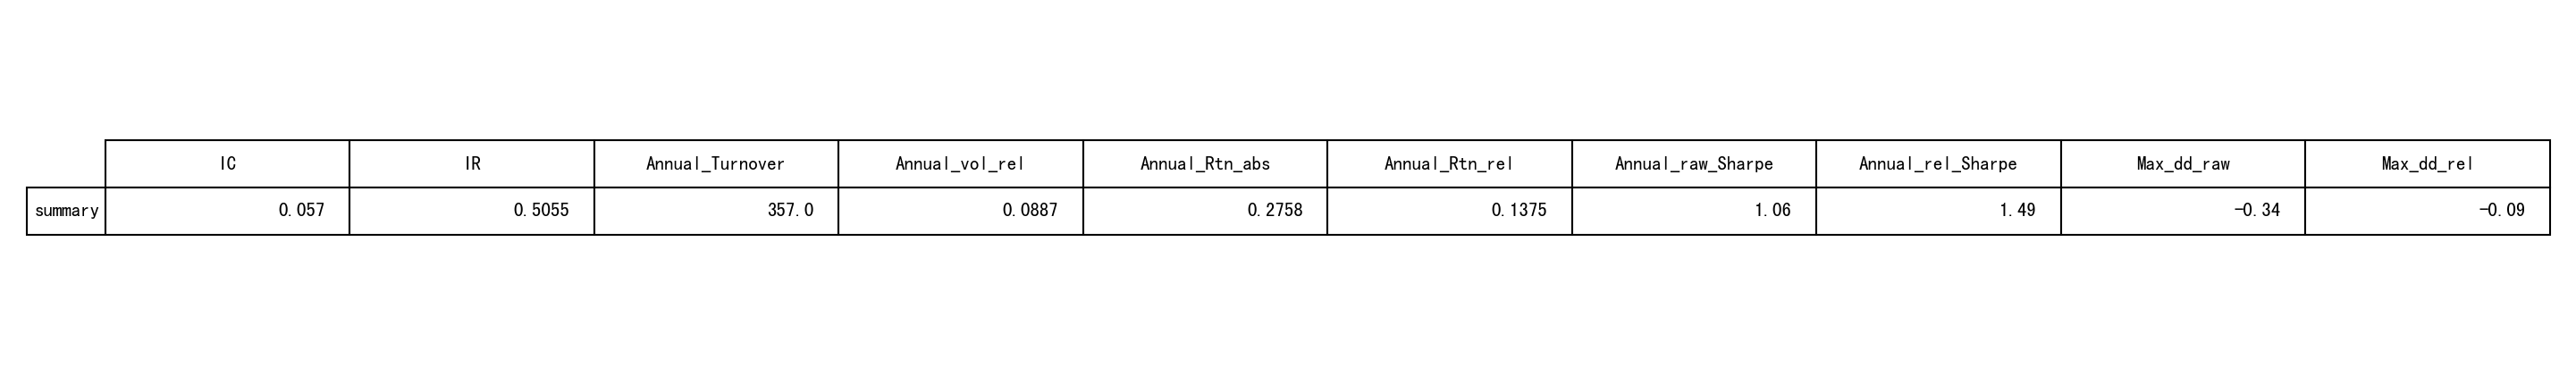

In [12]:
factor_source = FactorSourceConfig(
    factor_class="FactorsForTest",
    factor_group="cnn_baseline",
    factor_name="cnn_all_ticker_channel_zs_amt_C9_H8_W8_lookback252_retrain20_horizon5",
    factor_fp="/home/wenqian/FactorsForTest/cnn_baseline/cnn_all_ticker_channel_zs_amt_C9_H8_W8_lookback252_retrain20_horizon5.h5"
)
config = CrossSectionalConfig(
    start_date=20230401,
    end_date=20260210,
    freq="D",
    largest=True,
    trd_price="close",
    stock_pool="ZZQZ",
    index="2000",
    indus_neutral=False,
    indus="citic_1",
    stock_num=300,
    fee_rate=0.0,
    seasonal="Month",
    group_ind_neutral=False,
    group_idx_weight=False,
    group_num=20,
)

results = run_full_factor_analysis_from_source(
    config=config, factor_source=factor_source
)

plot_long_pnl(results.long_short, config, notebook=True)
plot_cash_series(results.long_short, notebook=True)
plot_ic_month(results.long_short, notebook=True)
plot_ic_decay(results.long_short, notebook=True)
plot_cover_rate(results.long_short, notebook=True)
plot_group_abs(results.group, config, notebook=True)
plot_group_rel(results.group, config, notebook=True)
plot_yearly_stats_table(results.long_short, notebook=True)
plot_summary_table(results.long_short, notebook=True)

**与现有的level2多因子对比**
---

In [ ]:
factor_sources = build_factor_sources_from_group(
    factor_class="FactorsForTest",
    factor_group="cnn_baseline_exsiting_l2",
)

configs = build_config_grid(
    base_config=base_config,
    param_grid={
        "stock_num": [200],
        "indus_neutral": [False],
    },
)

tasks = build_batch_tasks(
    factor_sources=factor_sources,
    configs=configs,
)

results = run_batch_tasks(
    tasks=tasks,
    n_jobs="auto",
)

compare_summary = build_compare_summary(results)
curve_df = compare_long_short_curves(results)
group_df = compare_group_head_tail(results)

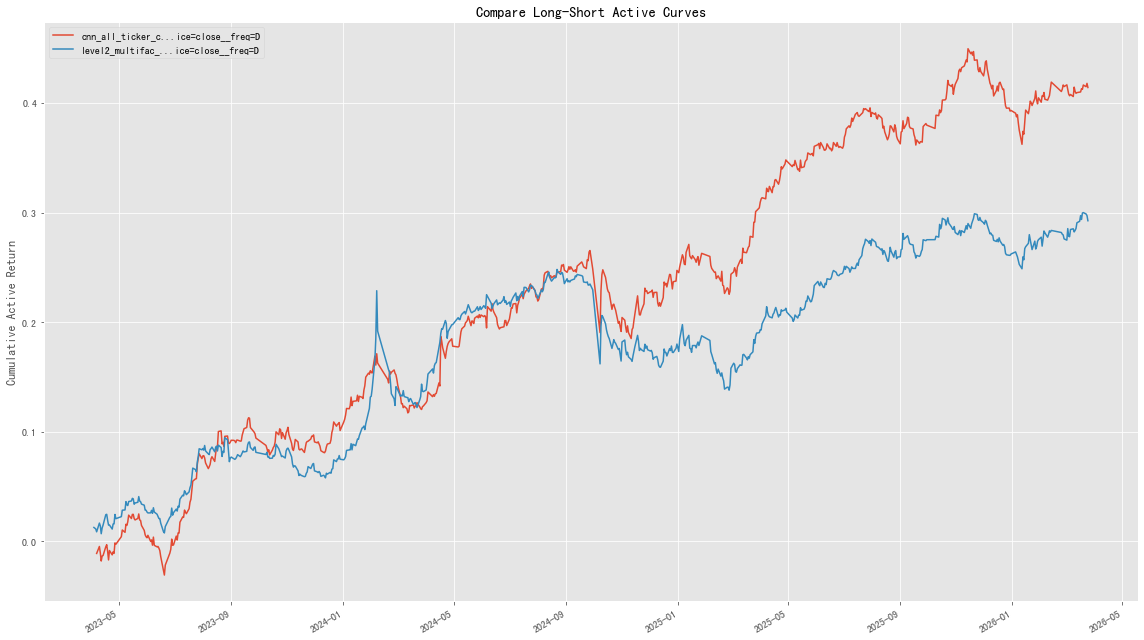

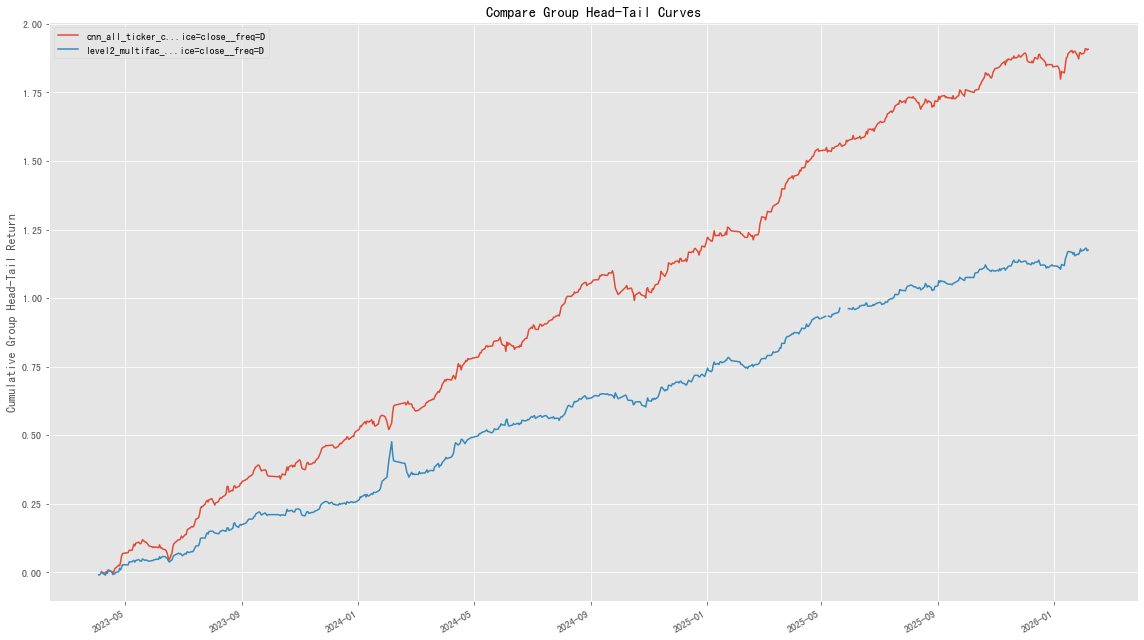

,IC,IR,Annual_Turnover,Annual_Rtn_rel,Annual_rel_Sharpe,Max_dd_rel
cnn_all_ticker_channel_zs_amt_C9_H8_W8_lookback252_retrain20_horizon5,0.0570,0.5055,383.0,0.1413,1.50,-0.09
level2_multifac,0.0373,0.4722,459.0,0.0996,1.08,-0.11


In [31]:
stock_num = 200
filtered_summary = filter_res_by_stock_num(df = compare_summary, stock_num=stock_num, index_or_col="index")
filtered_excess = filter_res_by_stock_num(df = curve_df, stock_num=stock_num, index_or_col="column")
filtered_ls = filter_res_by_stock_num(df = group_df, stock_num=stock_num, index_or_col="column")

plot_compare_long_short_curves(filtered_excess)
plot_compare_group_head_tail(filtered_ls)
display(filter_summary(filtered_summary))